# Практический анализ данных на языке Python — Лабораторная работа  
**Датасет:** Turkey Student Evaluation (Likert 1–5, Q1–Q28)  
**Среда:** Google Colab / Python 3, `pandas`, `numpy`, `matplotlib`, `seaborn`

**Структура ноутбука:**
- Введение / Описание данных
- Задание 1. Анализ и удаление выбросов
- Задание 2. Корреляционный анализ
- Задание 3. Сравнение матриц корреляций по предметам
- Задание 4. Описательная статистика по преподавателям
- Задание 5. Описательная статистика по предметам
- Выводы


In [12]:

# =====================
# Импорт библиотек и общие настройки графиков
# =====================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from collections import Counter

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
sns.set(style="whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Введение / Описание данных

В этой работе используется набор **Turkey Student Evaluation**: ответы студентов по 28 вопросам (Likert 1–5), а также поля `instr` (преподаватель), `class` (предмет/курс), `attendance` (посещаемость), `nb.repeat` (сколько раз студент проходил курс), `difficulty` (сложность курса) и др.



In [13]:

# =====================
# Загрузка данных из Google Drive
# =====================

from google.colab import drive
drive.mount('/content/drive')
path = '/content/drive/MyDrive/turkiye-student-evaluation_generic.csv'

import pandas as pd

# Читаем CSV
df = pd.read_csv(path)
print("Размерность:", df.shape)
display(df.head())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Размерность: (5820, 33)


,instr,class,nb.repeat,attendance,difficulty,Q1,Q2,Q3,Q4,Q5,...,Q19,Q20,Q21,Q22,Q23,Q24,Q25,Q26,Q27,Q28
0,1,2,1,0,4,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
1,1,2,1,1,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
2,1,2,1,2,4,5,5,5,5,5,...,5,5,5,5,5,5,5,5,5,5
3,1,2,1,1,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
4,1,2,1,0,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


In [14]:

# Опишем состав столбцов и типы
df_info = pd.DataFrame({
    "column": df.columns,
    "dtype": [df[c].dtype for c in df.columns],
})
display(df_info)

# Выделим группы признаков
id_cols = []
student_cols = []
question_cols = []
other_cols = []

for col in df.columns:
    if col in ["instr", "class"]:
        id_cols.append(col)
    elif col in ["attendance", "nb.repeat", "repeat", "gender", "age"]:
        student_cols.append(col)
    elif col.startswith("Q"):
        # Попробуем отфильтровать только Q1..Q28
        try:
            qnum = int(col[1:])
            if 1 <= qnum <= 28:
                question_cols.append(col)
            else:
                other_cols.append(col)
        except:
            other_cols.append(col)
    elif col == "difficulty":
        other_cols.append(col)
    else:
        other_cols.append(col)

print("ID-колонки:", id_cols)
print("Характеристики студента:", student_cols)
print("Вопросы Q1–Q28:", len(question_cols), "шт.")
print("Прочее:", other_cols)


,column,dtype
0,instr,int64
1,class,int64
2,nb.repeat,int64
3,attendance,int64
4,difficulty,int64
5,Q1,int64
6,Q2,int64
7,Q3,int64
8,Q4,int64
9,Q5,int64


ID-колонки: ['instr', 'class']
Характеристики студента: ['nb.repeat', 'attendance']
Вопросы Q1–Q28: 28 шт.
Прочее: ['difficulty']


## Задание 1. Анализ и удаление выбросов

Особенности анкетных данных (Likert 1–5) требуют аккуратного подхода к «выбросам».  
В этой работе применим **логические критерии качества ответов**:

1. **Нулевая/очень низкая посещаемость**: удаляем записи с `attendance == 0` (и при необходимости `attendance == 1`) как потенциально ненадёжные ответы.
2. **Стрейтлайнинг (straightlining)**: если ≥ 70% ответов по Q1–Q28 одинаковы (одна и та же оценка), считаем, что студент механически кликал одну и ту же галочку, и удаляем запись.
3. **Точные дубликаты** (по всем столбцам) — опционально удаляем.

Подсчитаем, сколько строк было изначально, сколько удалили по каждому правилу, и получим очищенный `df_clean`.


In [15]:

# =====================
# Функции для очистки
# =====================

# Унифицируем имя столбца повторов курса (в датасетах встречается и 'nb.repeat', и 'repeat')
if "nb.repeat" in df.columns and "repeat" not in df.columns:
    df = df.rename(columns={"nb.repeat": "repeat"})

def compute_straightline_share(row, qcols):
    vals = row[qcols].values
    counts = Counter(vals)
    most_common = counts.most_common(1)[0][1]
    return most_common / len(qcols)

initial_rows = len(df)

# 1) Фильтр по посещаемости
mask_att0 = (df["attendance"] == 0) if "attendance" in df.columns else pd.Series(False, index=df.index)
removed_att0 = mask_att0.sum()

# По желанию можно убрать и attendance == 1 (раскомментируйте при необходимости)
mask_att1 = (df["attendance"] == 1) if "attendance" in df.columns else pd.Series(False, index=df.index)
removed_att1 = mask_att1.sum()

# 2) Стрейтлайнинг: >= 70% одинаковых ответов среди Q1..Q28
straightline_threshold = 0.70
straightline_share = df.apply(lambda r: compute_straightline_share(r, question_cols), axis=1)
mask_straight = straightline_share >= straightline_threshold
removed_straight = mask_straight.sum()

# 3) Дубликаты (по всем столбцам)
mask_dups = df.duplicated(keep='first')
removed_dups = mask_dups.sum()

# Применяем удаление (по умолчанию удаляем attendance==0 и стрейтлайнинг, дубликаты — тоже)
to_drop_idx = df.index[mask_att0 | mask_straight | mask_dups]
df_clean = df.drop(index=to_drop_idx).copy()

print(f"Всего строк изначально: {initial_rows}")
print(f"Удалено по правилу attendance==0: {removed_att0}")
print(f"(опционально) Всего строк с attendance==1: {removed_att1}")
print(f"Удалено за стрейтлайнинг (>= {int(straightline_threshold*100)}% одинаковых ответов): {removed_straight}")
print(f"Удалено дубликатов: {removed_dups}")
print(f"Осталось после очистки: {len(df_clean)}")


Всего строк изначально: 5820
Удалено по правилу attendance==0: 1902
(опционально) Всего строк с attendance==1: 1028
Удалено за стрейтлайнинг (>= 70% одинаковых ответов): 4087
Удалено дубликатов: 1843
Осталось после очистки: 1322


**После очистки данных были удалены записи с нулевой посещаемостью и ответы с признаками «стрейтлайнинга» (более 70% одинаковых оценок).
Это повысило достоверность анализа: оставшиеся ответы с большей вероятностью отражают реальные впечатления студентов.
Таким образом, очистка данных обеспечила основу для корректного статистического анализа.**

## Задание 2. Корреляционный анализ критериев качества преподавания

Построим матрицу корреляций для `Q1–Q28` и `difficulty`. Для данных с порядковой шкалой Лайкерта разумно использовать **ранговую корреляцию Спирмена**, поскольку она менее чувствительна к нелинейностям и допускает порядковую природу шкалы.


,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,Q20,Q21,Q22,Q23,Q24,Q25,Q26,Q27,Q28,difficulty
Q1,1.000,0.691,0.387,0.654,0.510,0.397,0.475,0.490,0.330,0.498,...,0.214,0.180,0.171,0.323,0.323,0.177,0.259,0.290,0.167,-0.008
Q2,0.691,1.000,0.507,0.639,0.564,0.468,0.504,0.486,0.424,0.547,...,0.337,0.304,0.323,0.395,0.389,0.316,0.351,0.319,0.295,-0.054
Q3,0.387,0.507,1.000,0.434,0.468,0.398,0.393,0.378,0.338,0.443,...,0.305,0.297,0.288,0.331,0.330,0.292,0.333,0.255,0.293,-0.101
Q4,0.654,0.639,0.434,1.000,0.559,0.470,0.494,0.456,0.328,0.490,...,0.265,0.254,0.247,0.355,0.344,0.252,0.300,0.279,0.236,-0.022
Q5,0.510,0.564,0.468,0.559,1.000,0.569,0.626,0.613,0.379,0.610,...,0.326,0.283,0.280,0.441,0.451,0.276,0.379,0.331,0.259,-0.036
Q6,0.397,0.468,0.398,0.470,0.569,1.000,0.617,0.503,0.315,0.548,...,0.267,0.228,0.241,0.319,0.303,0.215,0.313,0.256,0.263,-0.074
Q7,0.475,0.504,0.393,0.494,0.626,0.617,1.000,0.673,0.408,0.620,...,0.280,0.242,0.248,0.404,0.417,0.253,0.345,0.332,0.224,-0.059
Q8,0.490,0.486,0.378,0.456,0.613,0.503,0.673,1.000,0.422,0.637,...,0.264,0.214,0.222,0.418,0.442,0.249,0.353,0.352,0.201,-0.034
Q9,0.330,0.424,0.338,0.328,0.379,0.315,0.408,0.422,1.000,0.565,...,0.276,0.291,0.296,0.328,0.275,0.267,0.281,0.275,0.251,-0.107
Q10,0.498,0.547,0.443,0.490,0.610,0.548,0.620,0.637,0.565,1.000,...,0.356,0.331,0.342,0.463,0.465,0.313,0.445,0.406,0.299,-0.126


Порядок переменных в корреляционной матрице:
['instr_code', 'class_code', 'repeat', 'attendance', 'difficulty', 'Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10', 'Q11', 'Q12', 'Q13', 'Q14', 'Q15', 'Q16', 'Q17', 'Q18', 'Q19', 'Q20', 'Q21', 'Q22', 'Q23', 'Q24', 'Q25', 'Q26', 'Q27', 'Q28']


,instr_code,class_code,repeat,attendance,difficulty,Q1,Q2,Q3,Q4,Q5,...,Q19,Q20,Q21,Q22,Q23,Q24,Q25,Q26,Q27,Q28
instr_code,1.00,-0.13,0.13,-0.02,0.08,-0.16,-0.13,-0.10,-0.10,-0.16,...,-0.10,-0.01,-0.00,-0.00,-0.13,-0.13,0.01,-0.06,-0.08,-0.00
class_code,-0.13,1.00,0.03,0.05,-0.15,-0.02,-0.00,0.06,0.01,-0.02,...,0.06,0.02,0.04,0.05,0.04,-0.01,0.02,0.02,0.06,-0.01
repeat,0.13,0.03,1.00,-0.13,-0.07,-0.03,-0.07,-0.02,-0.06,-0.02,...,-0.05,-0.03,-0.02,-0.02,-0.05,-0.01,-0.06,0.00,-0.00,-0.02
attendance,-0.02,0.05,-0.13,1.00,-0.02,-0.01,0.03,0.05,0.00,-0.00,...,0.06,0.08,0.10,0.11,0.06,0.02,0.08,0.05,-0.02,0.06
difficulty,0.08,-0.15,-0.07,-0.02,1.00,-0.01,-0.05,-0.10,-0.02,-0.04,...,-0.12,-0.05,-0.07,-0.07,-0.07,-0.04,-0.04,-0.11,-0.06,-0.07
Q1,-0.16,-0.02,-0.03,-0.01,-0.01,1.00,0.69,0.39,0.65,0.51,...,0.25,0.21,0.18,0.17,0.32,0.32,0.18,0.26,0.29,0.17
Q2,-0.13,-0.00,-0.07,0.03,-0.05,0.69,1.00,0.51,0.64,0.56,...,0.36,0.34,0.30,0.32,0.39,0.39,0.32,0.35,0.32,0.30
Q3,-0.10,0.06,-0.02,0.05,-0.10,0.39,0.51,1.00,0.43,0.47,...,0.32,0.31,0.30,0.29,0.33,0.33,0.29,0.33,0.26,0.29
Q4,-0.10,0.01,-0.06,0.00,-0.02,0.65,0.64,0.43,1.00,0.56,...,0.30,0.26,0.25,0.25,0.35,0.34,0.25,0.30,0.28,0.24
Q5,-0.16,-0.02,-0.02,-0.00,-0.04,0.51,0.56,0.47,0.56,1.00,...,0.37,0.33,0.28,0.28,0.44,0.45,0.28,0.38,0.33,0.26


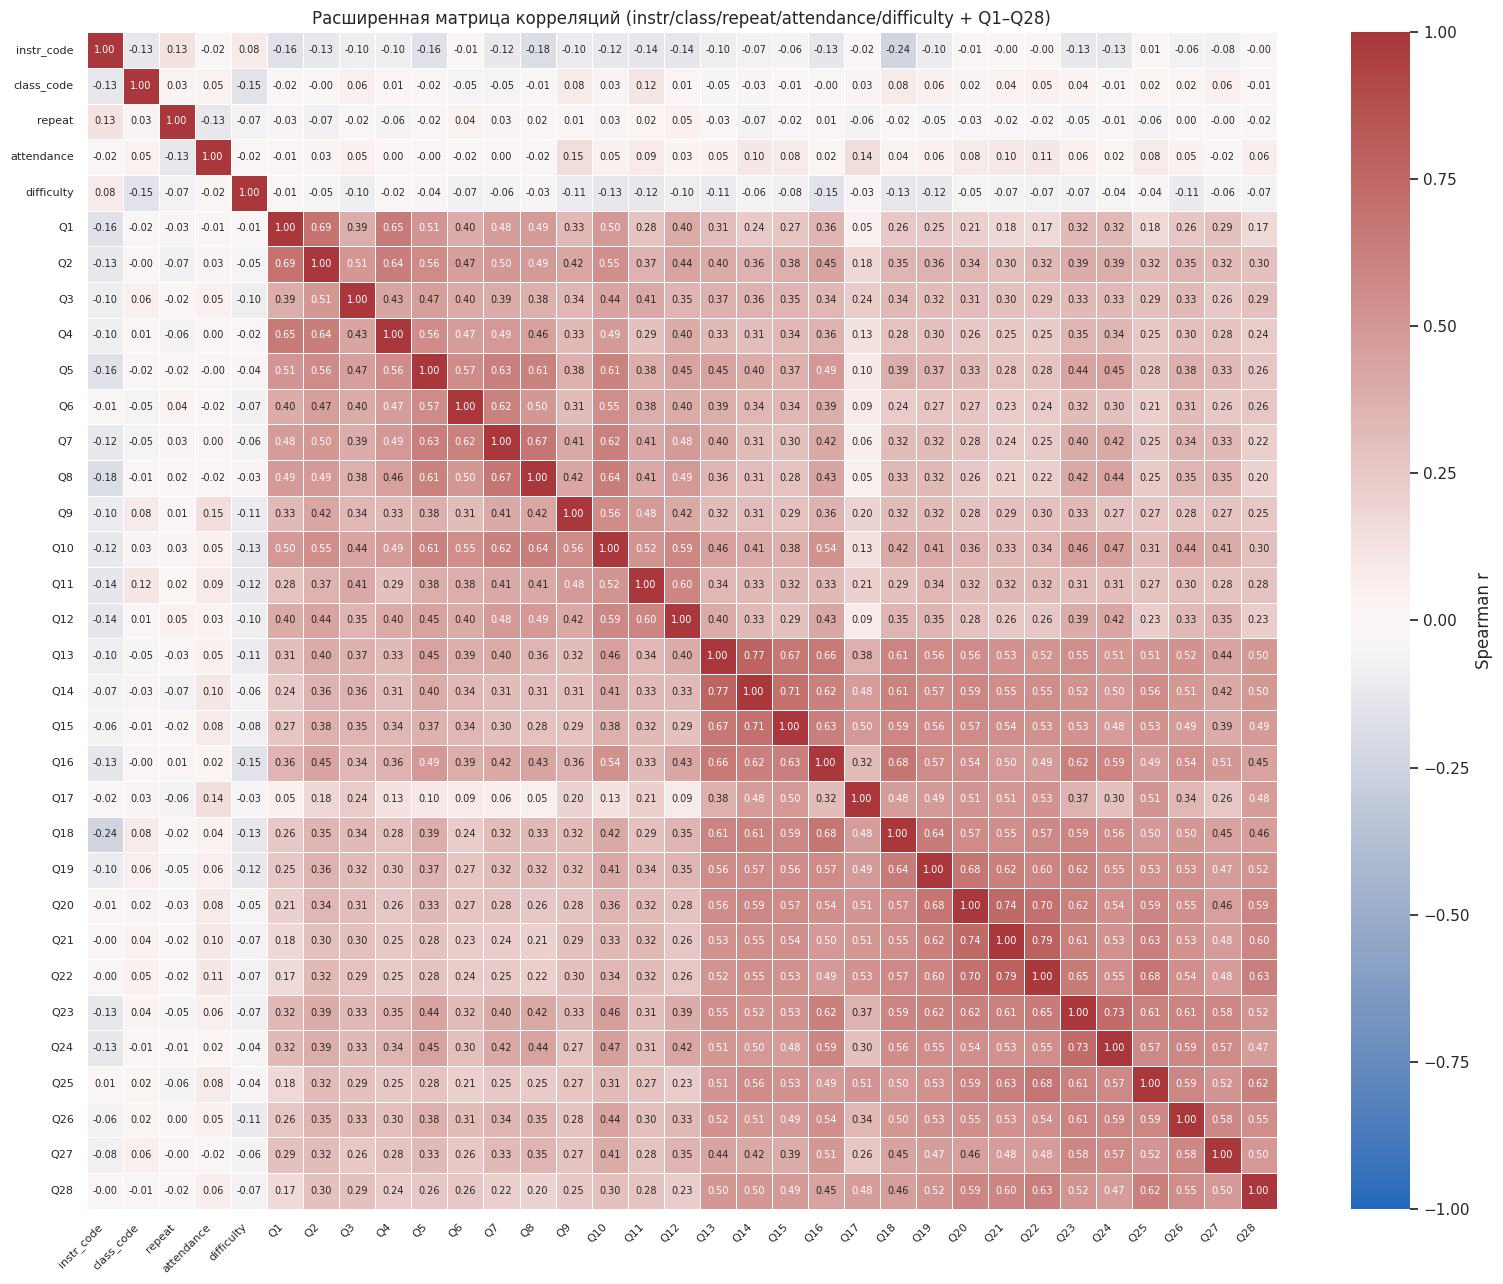

In [18]:

# # =====================
# # Матрица корреляций (Spearman)
# # =====================
corr_cols = question_cols + (["difficulty"] if "difficulty" in df_clean.columns else [])
corr_df = df_clean[corr_cols].corr(method="spearman")
display(corr_df.round(3))

df_corr = df_clean.copy()

# Преобразуем категориальные переменные в числовые коды
df_corr["instr_code"] = df_corr["instr"].astype("category").cat.codes
df_corr["class_code"] = df_corr["class"].astype("category").cat.codes

# Определим колонку повторов курса
if "nb.repeat" in df_corr.columns:
    repeat_col = "nb.repeat"
elif "repeat" in df_corr.columns:
    repeat_col = "repeat"
else:
    repeat_col = None

# Формируем список переменных: сначала контекстные, потом вопросы
context_vars = ["instr_code", "class_code", "attendance", "difficulty"]
if repeat_col:
    context_vars.insert(2, repeat_col)  # вставляем repeat после class

# Вопросы Q1–Q28
question_vars = [c for c in df_corr.columns if c.startswith("Q") and c[1:].isdigit()]
question_vars = sorted(question_vars, key=lambda x: int(x[1:]))  # сортировка по номеру

# Финальный список переменных для корреляции
corr_vars = context_vars + question_vars
print("Порядок переменных в корреляционной матрице:")
print(corr_vars)

# Корреляции (Spearman)
corr_extended = df_corr[corr_vars].corr(method="spearman")
display(corr_extended.round(2))

# Тепловая карта с аннотациями
plt.figure(figsize=(16, 13))
sns.heatmap(
    corr_extended,
    cmap="vlag",
    vmin=-1, vmax=1, center=0,
    annot=True, fmt=".2f",
    annot_kws={"size":7},
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Spearman r"}
)
plt.title("Расширенная матрица корреляций (instr/class/repeat/attendance/difficulty + Q1–Q28)")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()


In [19]:

# =====================
# Явный вывод пар по уровням силы связи
# =====================
def list_pairs_by_strength(corr, strong=0.7, moderate=(0.5, 0.7), weak=0.3):
    pairs_strong = []
    pairs_moderate = []
    pairs_weak = []
    cols = corr.columns
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            r = corr.iloc[i, j]
            a, b = cols[i], cols[j]
            if abs(r) >= strong:
                pairs_strong.append((a, b, r))
            elif moderate[0] <= abs(r) < moderate[1]:
                pairs_moderate.append((a, b, r))
            elif abs(r) < weak:
                pairs_weak.append((a, b, r))
    return (
        sorted(pairs_strong, key=lambda x: -abs(x[2])),
        sorted(pairs_moderate, key=lambda x: -abs(x[2])),
        sorted(pairs_weak, key=lambda x: abs(x[2])),
    )

pairs_strong, pairs_moderate, pairs_weak = list_pairs_by_strength(corr_df)

print("Сильные корреляции (|r| >= 0.7):", len(pairs_strong))
for a,b,r in pairs_strong[:20]:
    print(f"{a} — {b}: r={r:.3f}")

print("\nУмеренные корреляции (0.5 <= |r| < 0.7):", len(pairs_moderate))
for a,b,r in pairs_moderate[:20]:
    print(f"{a} — {b}: r={r:.3f}")

print("\nСлабые корреляции (|r| < 0.3):", len(pairs_weak))
for a,b,r in pairs_weak[:20]:
    print(f"{a} — {b}: r={r:.3f}")


Сильные корреляции (|r| >= 0.7): 6
Q21 — Q22: r=0.789
Q13 — Q14: r=0.774
Q20 — Q21: r=0.739
Q23 — Q24: r=0.733
Q14 — Q15: r=0.710
Q20 — Q22: r=0.704

Умеренные корреляции (0.5 <= |r| < 0.7): 107
Q1 — Q2: r=0.691
Q19 — Q20: r=0.683
Q16 — Q18: r=0.681
Q22 — Q25: r=0.678
Q7 — Q8: r=0.673
Q13 — Q15: r=0.667
Q13 — Q16: r=0.664
Q1 — Q4: r=0.654
Q22 — Q23: r=0.648
Q18 — Q19: r=0.644
Q2 — Q4: r=0.639
Q8 — Q10: r=0.637
Q15 — Q16: r=0.630
Q22 — Q28: r=0.630
Q21 — Q25: r=0.628
Q5 — Q7: r=0.626
Q19 — Q21: r=0.625
Q20 — Q23: r=0.624
Q7 — Q10: r=0.620
Q14 — Q16: r=0.619

Слабые корреляции (|r| < 0.3): 114
Q1 — difficulty: r=-0.008
Q4 — difficulty: r=-0.022
Q17 — difficulty: r=-0.033
Q8 — difficulty: r=-0.034
Q5 — difficulty: r=-0.036
Q25 — difficulty: r=-0.037
Q24 — difficulty: r=-0.041
Q1 — Q17: r=0.048
Q2 — difficulty: r=-0.054
Q20 — difficulty: r=-0.054
Q8 — Q17: r=0.055
Q27 — difficulty: r=-0.055
Q7 — difficulty: r=-0.059
Q14 — difficulty: r=-0.062
Q7 — Q17: r=0.064
Q28 — difficulty: r=-0.069
Q2

**Краткий анализ.**  
- Вопросы, относящиеся к смежным аспектам курса/преподавания, как правило, коррелируют сильнее. Например, для блока `Q13–Q28` (характеристики преподавателя) обычно наблюдается тесная взаимосвязь между соседними пунктами.
- Переменная `difficulty` часто имеет более слабую связь с оценками качества, т.к. сложность не всегда напрямую связана с удовлетворённостью студентом.


**Матрица корреляций показала сильные связи между вопросами внутри тематических блоков и слабые — между блоками.
Это означает, что студенты воспринимают отдельные аспекты качества преподавания осознанно и дифференцированно: преподаватель, структура курса и вовлечённость — это разные, но взаимосвязанные измерения обучения.
Переменная difficulty имеет более слабую корреляцию с оценками, что логично — сложность курса не всегда связана с восприятием качества преподавания.**

## Задание 3. Сравнение матриц корреляций для разных предметов


In [25]:

# =====================
# Сводка по курсам
# =====================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- ПАРАМЕТРЫ ---
MIN_N = 30                  # порог "достаточного" числа наблюдений на курс
STRONG_THR = 0.70           # сильные связи
MOD_LO, MOD_HI = 0.50, 0.70 # умеренные связи (по модулю)
WEAK_THR = 0.30             # слабые связи

# --- ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ ---
def get_question_vars(df_):
    q = [c for c in df_.columns if c.startswith("Q") and c[1:].isdigit()]
    q = [c for c in q if 1 <= int(c[1:]) <= 28]
    return sorted(q, key=lambda x: int(x[1:]))

def corr_summary(corr: pd.DataFrame,
                 strong=STRONG_THR,
                 moderate=(MOD_LO, MOD_HI),
                 weak=WEAK_THR):
    """Возвращает:
       - список сильных пар (имена, r), отсортированный по |r| по убыванию
       - количество умеренных пар
       - количество слабых пар
    """
    strong_pairs = []
    n_mod, n_weak = 0, 0
    cols = corr.columns
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            r = corr.iloc[i, j]
            if pd.isna(r):
                continue
            ar = abs(r)
            if ar >= strong:
                strong_pairs.append((cols[i], cols[j], float(r)))
            elif moderate[0] <= ar < moderate[1]:
                n_mod += 1
            elif ar < weak:
                n_weak += 1
    strong_pairs.sort(key=lambda x: -abs(x[2]))
    return strong_pairs, n_mod, n_weak

def plot_corr_heatmap(corr_df, title):
    plt.figure(figsize=(16, 13))
    sns.heatmap(
        corr_df,
        cmap="vlag",
        vmin=-1, vmax=1, center=0,
        annot=True, fmt=".2f",
        annot_kws={"size":7},
        linewidths=0.4, linecolor="white",
        cbar_kws={"label": "Spearman r"}
    )
    plt.title(title)
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.show()

# --- ПРОВЕРКИ ---
if "df_clean" not in globals():
    raise RuntimeError("df_clean не найден. Сначала выполните Задание 1 (загрузка и очистка данных).")

# --- 2) КОЛИЧЕСТВО УНИКАЛЬНЫХ КУРСОВ И ИХ СПИСКИ ---
class_counts = df_clean["class"].value_counts().sort_index()
unique_classes_sorted = sorted(class_counts.index.tolist(), key=lambda x: x)
enough_classes = [c for c in unique_classes_sorted if class_counts[c] >= MIN_N]
not_enough_classes = [c for c in unique_classes_sorted if class_counts[c] < MIN_N]

print("=== Сводка по курсам ===")
print(f"Всего уникальных курсов: {len(unique_classes_sorted)}")
print("Список курсов (отсортирован по номеру):")
print(unique_classes_sorted)
print(f"\nПорог достаточности данных на курс: n >= {MIN_N}")
print(f"Курсы с достаточным числом наблюдений ({len(enough_classes)} шт.):")
print(enough_classes if len(enough_classes) else "—")
print(f"\nКурсы с недостаточным числом наблюдений ({len(not_enough_classes)} шт.):")
print(not_enough_classes if len(not_enough_classes) else "—")

display(pd.DataFrame({"class": class_counts.index, "n": class_counts.values}))

# --- СПИСОК ВОПРОСОВ Q1–Q28 ---
question_vars = get_question_vars(df_clean)
if not question_vars:
    raise RuntimeError("Не найдены колонки Q1–Q28.")


=== Сводка по курсам ===
Всего уникальных курсов: 13
Список курсов (отсортирован по номеру):
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]

Порог достаточности данных на курс: n >= 30
Курсы с достаточным числом наблюдений (11 шт.):
[1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13]

Курсы с недостаточным числом наблюдений (2 шт.):
[2, 12]


,class,n
0,1,62
1,2,15
2,3,161
3,4,58
4,5,164
5,6,118
6,7,53
7,8,188
8,9,140
9,10,81


In [26]:

# --- СВОДКА ПО СИЛЕ КОРРЕЛЯЦИЙ ДЛЯ КАЖДОГО КУРСА ---
print("\n=== Сводка корреляций по каждому курсу ===")
summary_rows = []
for c in unique_classes_sorted:
    df_c = df_clean[df_clean["class"] == c]
    if len(df_c) < 2:
        # для корреляции нужно как минимум 2 строки
        summary_rows.append({
            "class": c,
            "n": len(df_c),
            "strong_pairs": 0,
            "moderate_pairs": 0,
            "weak_pairs": 0
        })
        continue
    corr_c = df_c[question_vars].corr(method="spearman")
    strong_pairs, n_mod, n_weak = corr_summary(corr_c)
    summary_rows.append({
        "class": c,
        "n": len(df_c),
        "strong_pairs": len(strong_pairs),
        "moderate_pairs": n_mod,
        "weak_pairs": n_weak
    })

summary_df = pd.DataFrame(summary_rows).sort_values(["n","class"])
display(summary_df)

# Также выведем Топ-10 сильнейших пар (по |r|) для курсов с достаточными данными
print("\n=== Топ-10 сильных корреляций по курсам (только n>=MIN_N) ===")
for c in enough_classes:
    df_c = df_clean[df_clean["class"] == c]
    corr_c = df_c[question_vars].corr(method="spearman")
    strong_pairs, n_mod, n_weak = corr_summary(corr_c)
    print(f"\nКурс {c} (n={len(df_c)}): сильных пар = {len(strong_pairs)}, умеренных = {n_mod}, слабых = {n_weak}")
    for a,b,r in strong_pairs[:10]:
        print(f"  {a} — {b}: r={r:.3f}")



=== Сводка корреляций по каждому курсу ===


,class,n,strong_pairs,moderate_pairs,weak_pairs
11,12,10,183,119,15
1,2,15,57,87,154
6,7,53,5,60,126
3,4,58,12,81,112
0,1,62,43,136,52
9,10,81,34,139,38
10,11,117,4,86,105
5,6,118,46,81,120
8,9,140,4,72,142
12,13,155,26,115,73



=== Топ-10 сильных корреляций по курсам (только n>=MIN_N) ===

Курс 1 (n=62): сильных пар = 43, умеренных = 136, слабых = 52
  Q13 — Q14: r=0.844
  Q21 — Q22: r=0.819
  Q16 — Q18: r=0.793
  Q14 — Q18: r=0.791
  Q16 — Q20: r=0.789
  Q18 — Q20: r=0.789
  Q20 — Q21: r=0.774
  Q14 — Q16: r=0.769
  Q19 — Q20: r=0.764
  Q18 — Q22: r=0.762

Курс 3 (n=161): сильных пар = 22, умеренных = 158, слабых = 37
  Q13 — Q14: r=0.823
  Q14 — Q15: r=0.800
  Q16 — Q18: r=0.796
  Q9 — Q10: r=0.794
  Q21 — Q22: r=0.766
  Q18 — Q19: r=0.762
  Q13 — Q15: r=0.746
  Q7 — Q8: r=0.745
  Q1 — Q2: r=0.744
  Q11 — Q12: r=0.738

Курс 4 (n=58): сильных пар = 12, умеренных = 81, слабых = 112
  Q1 — Q4: r=0.804
  Q20 — Q21: r=0.801
  Q7 — Q10: r=0.799
  Q7 — Q8: r=0.779
  Q23 — Q24: r=0.757
  Q6 — Q7: r=0.754
  Q6 — Q12: r=0.749
  Q5 — Q7: r=0.745
  Q5 — Q8: r=0.734
  Q6 — Q10: r=0.730

Курс 5 (n=164): сильных пар = 6, умеренных = 112, слабых = 92
  Q13 — Q14: r=0.824
  Q11 — Q12: r=0.769
  Q20 — Q21: r=0.729
  Q14 — Q


=== Построение матриц корреляций по каждому курсу ===


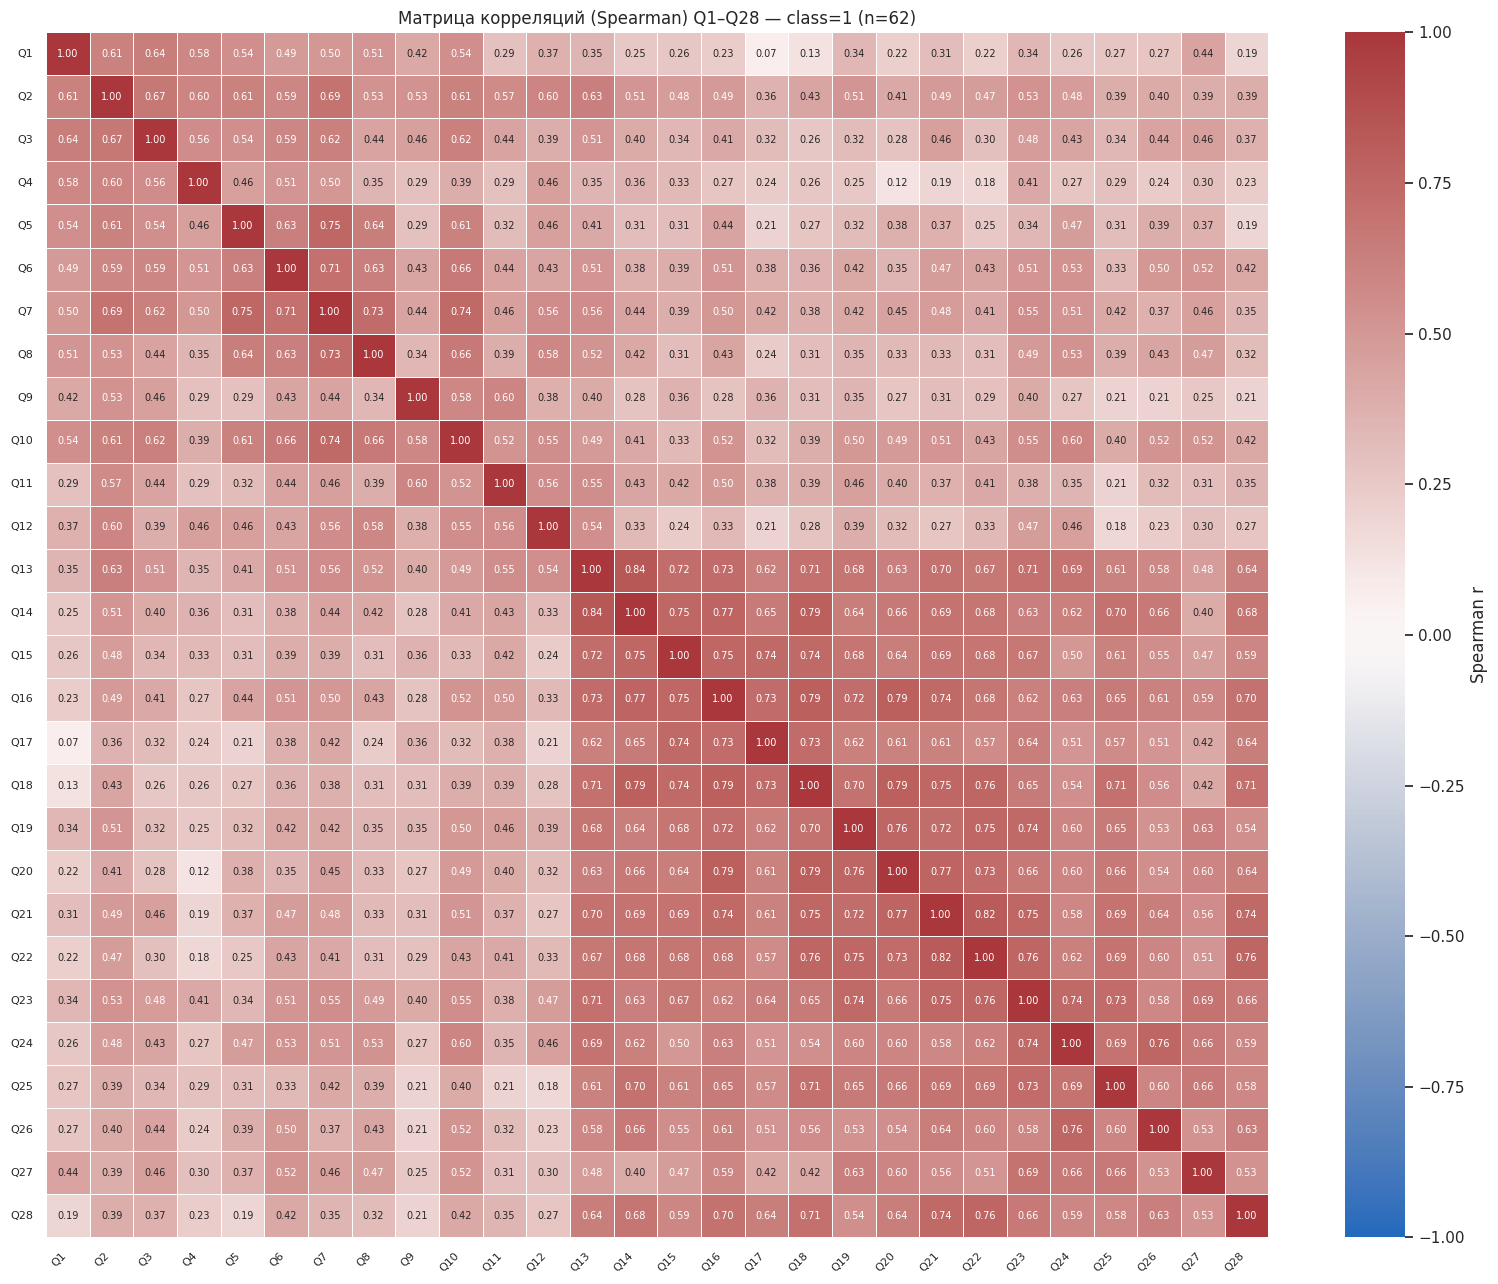

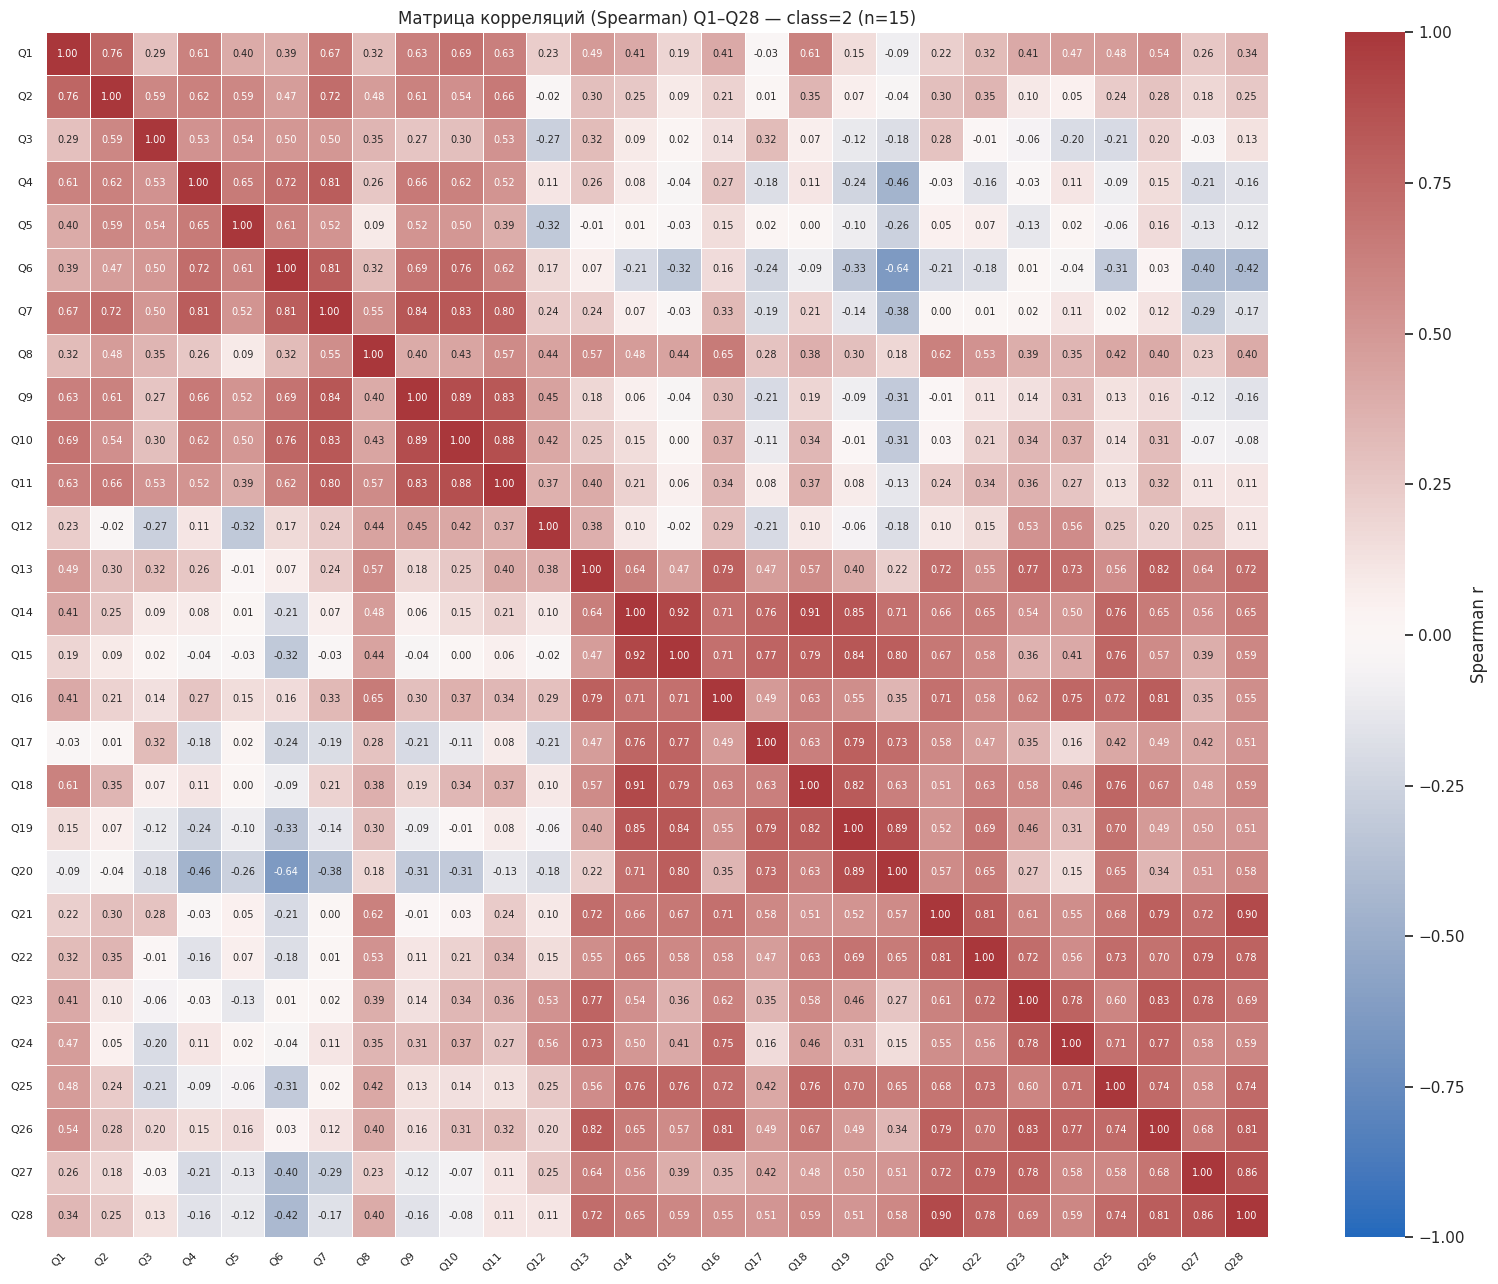

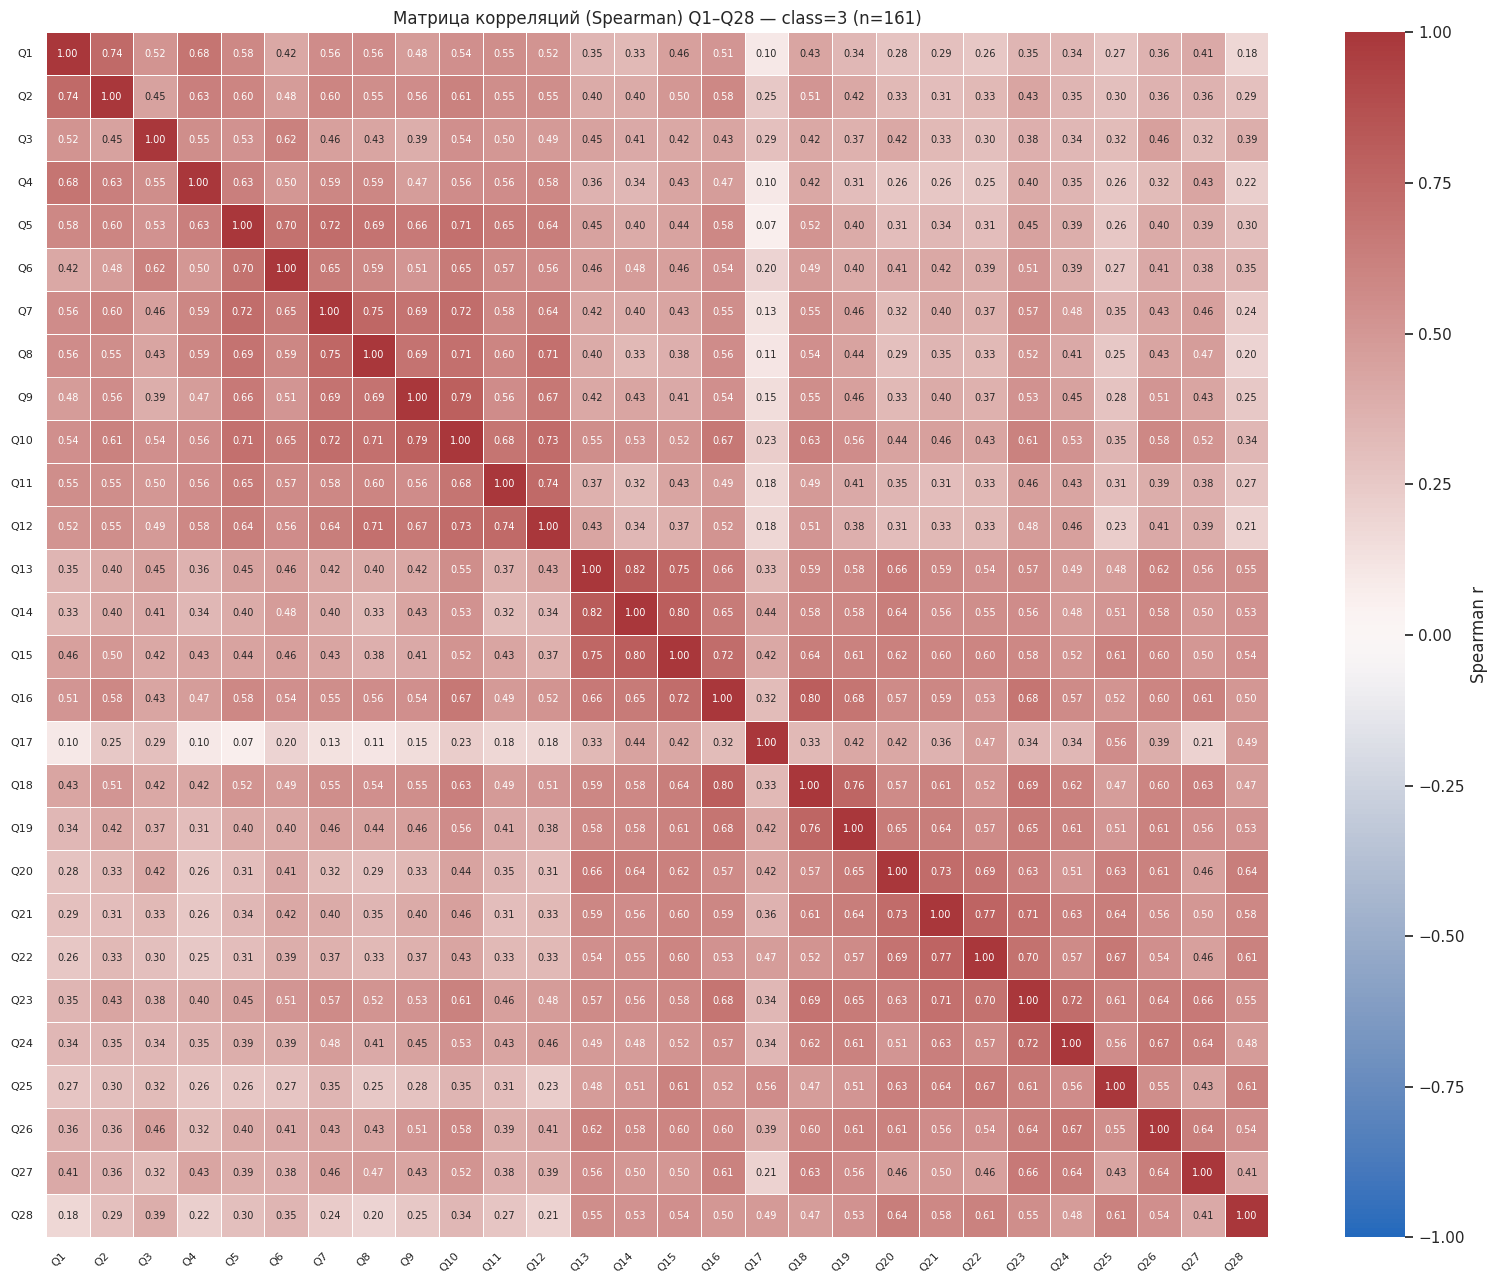

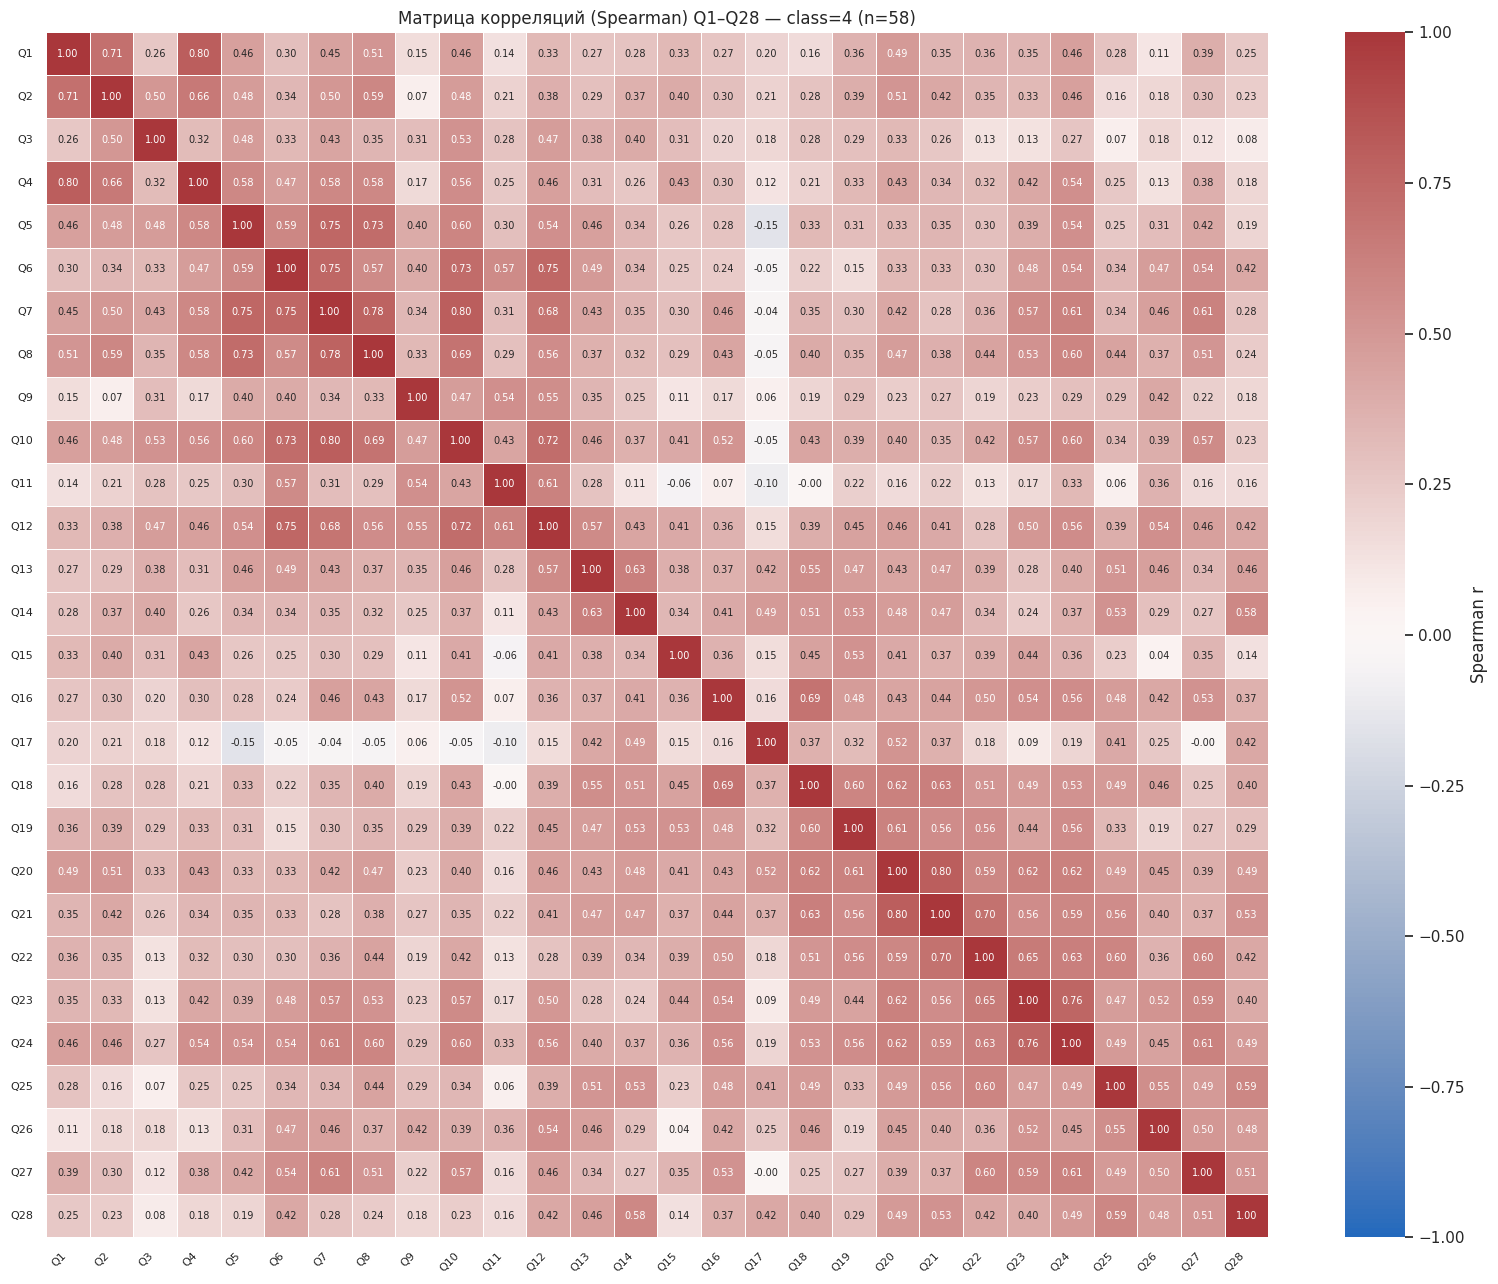

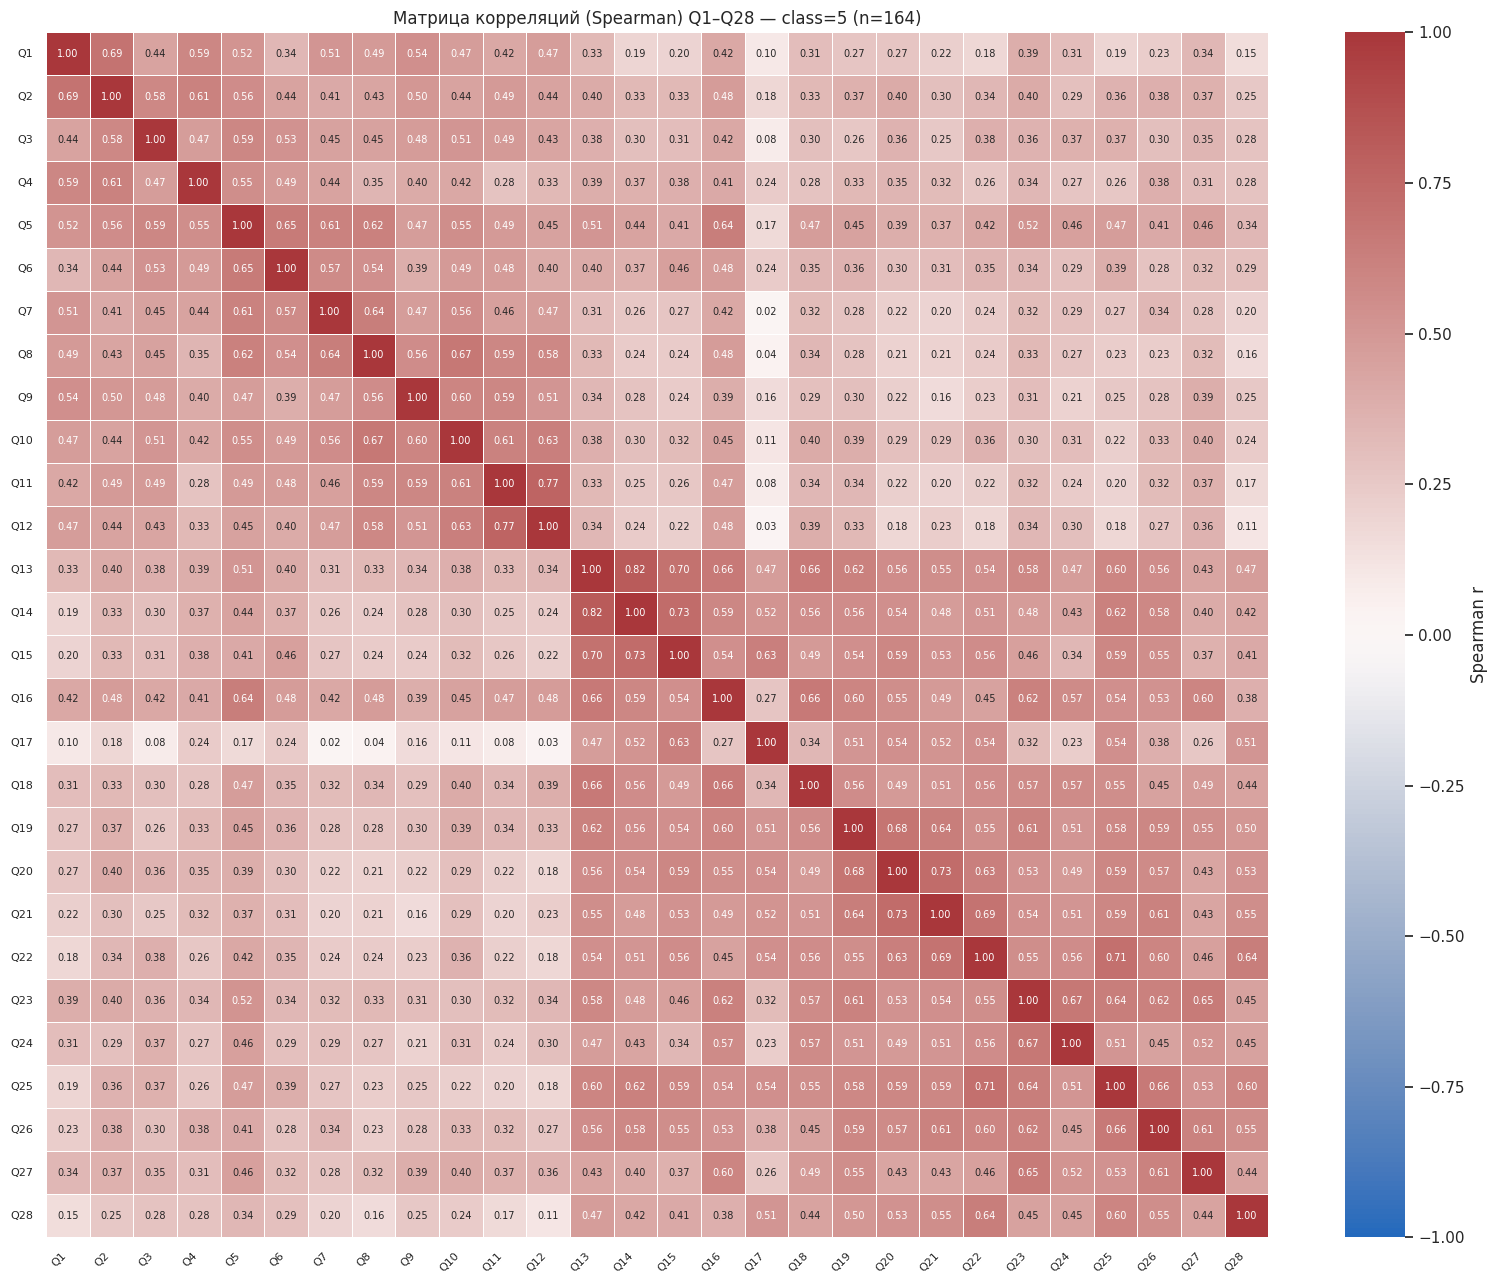

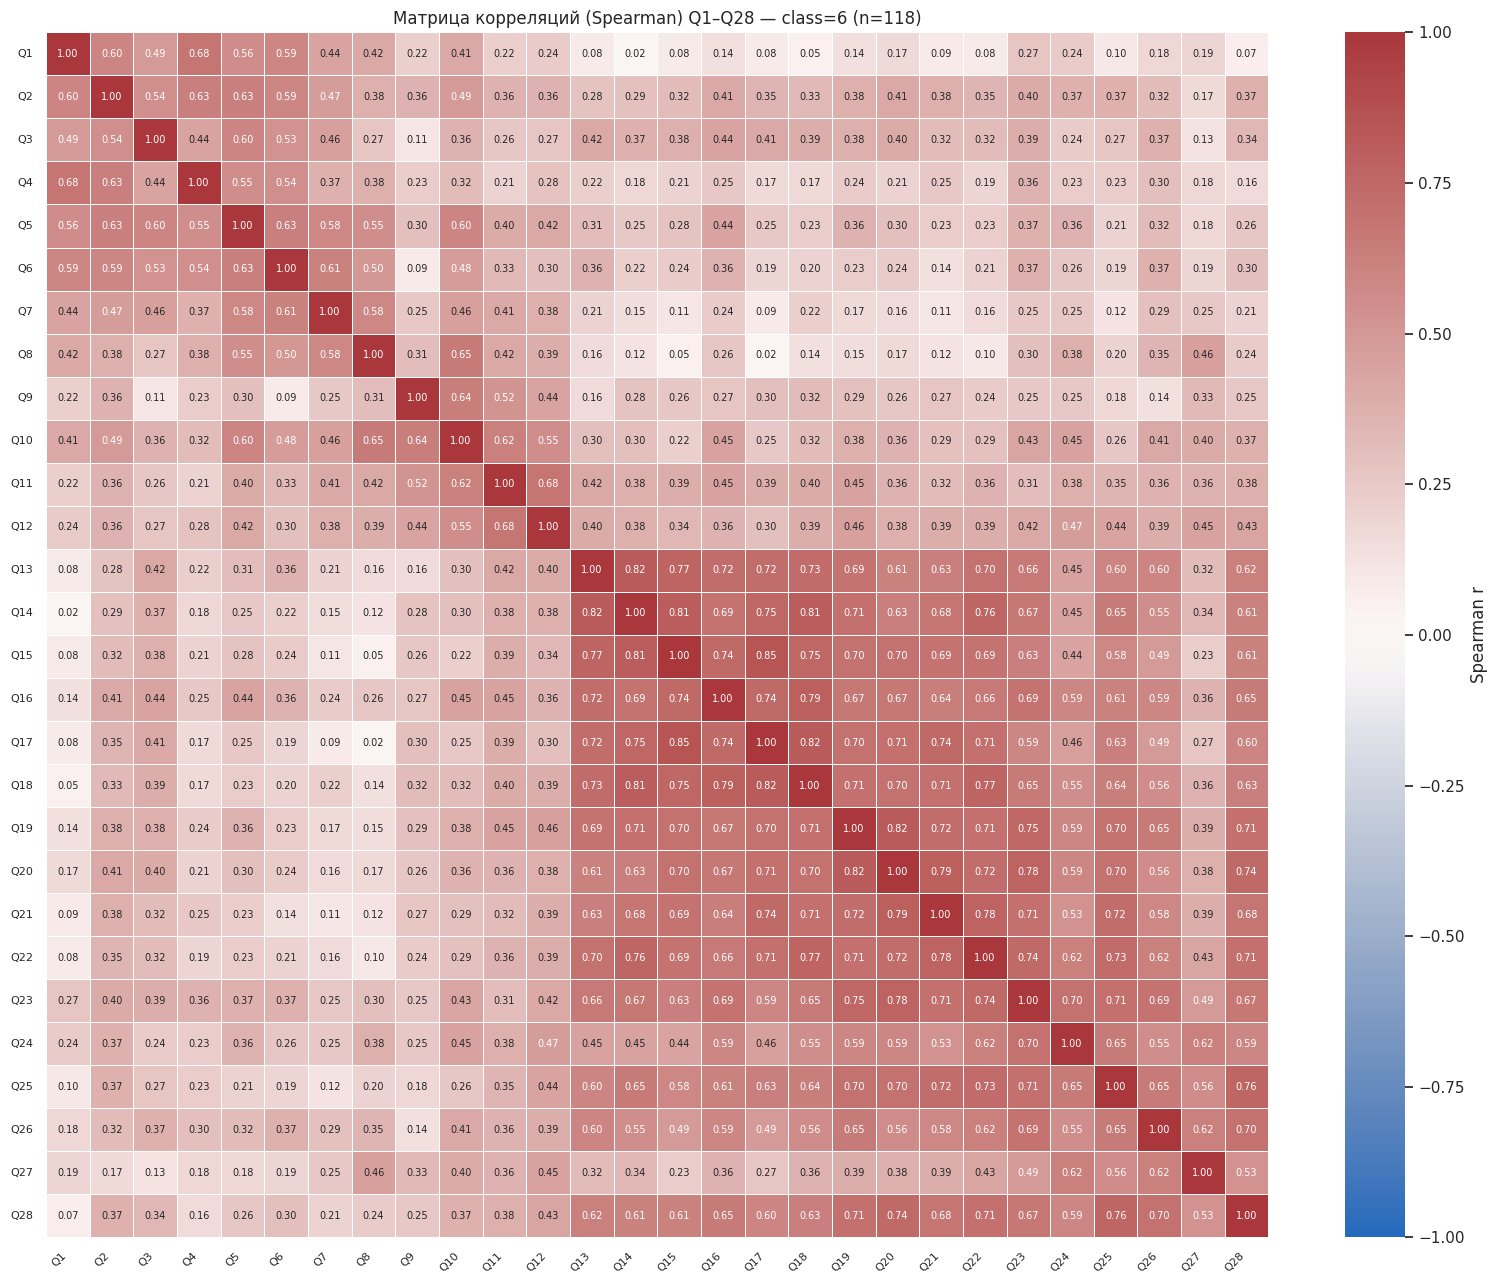

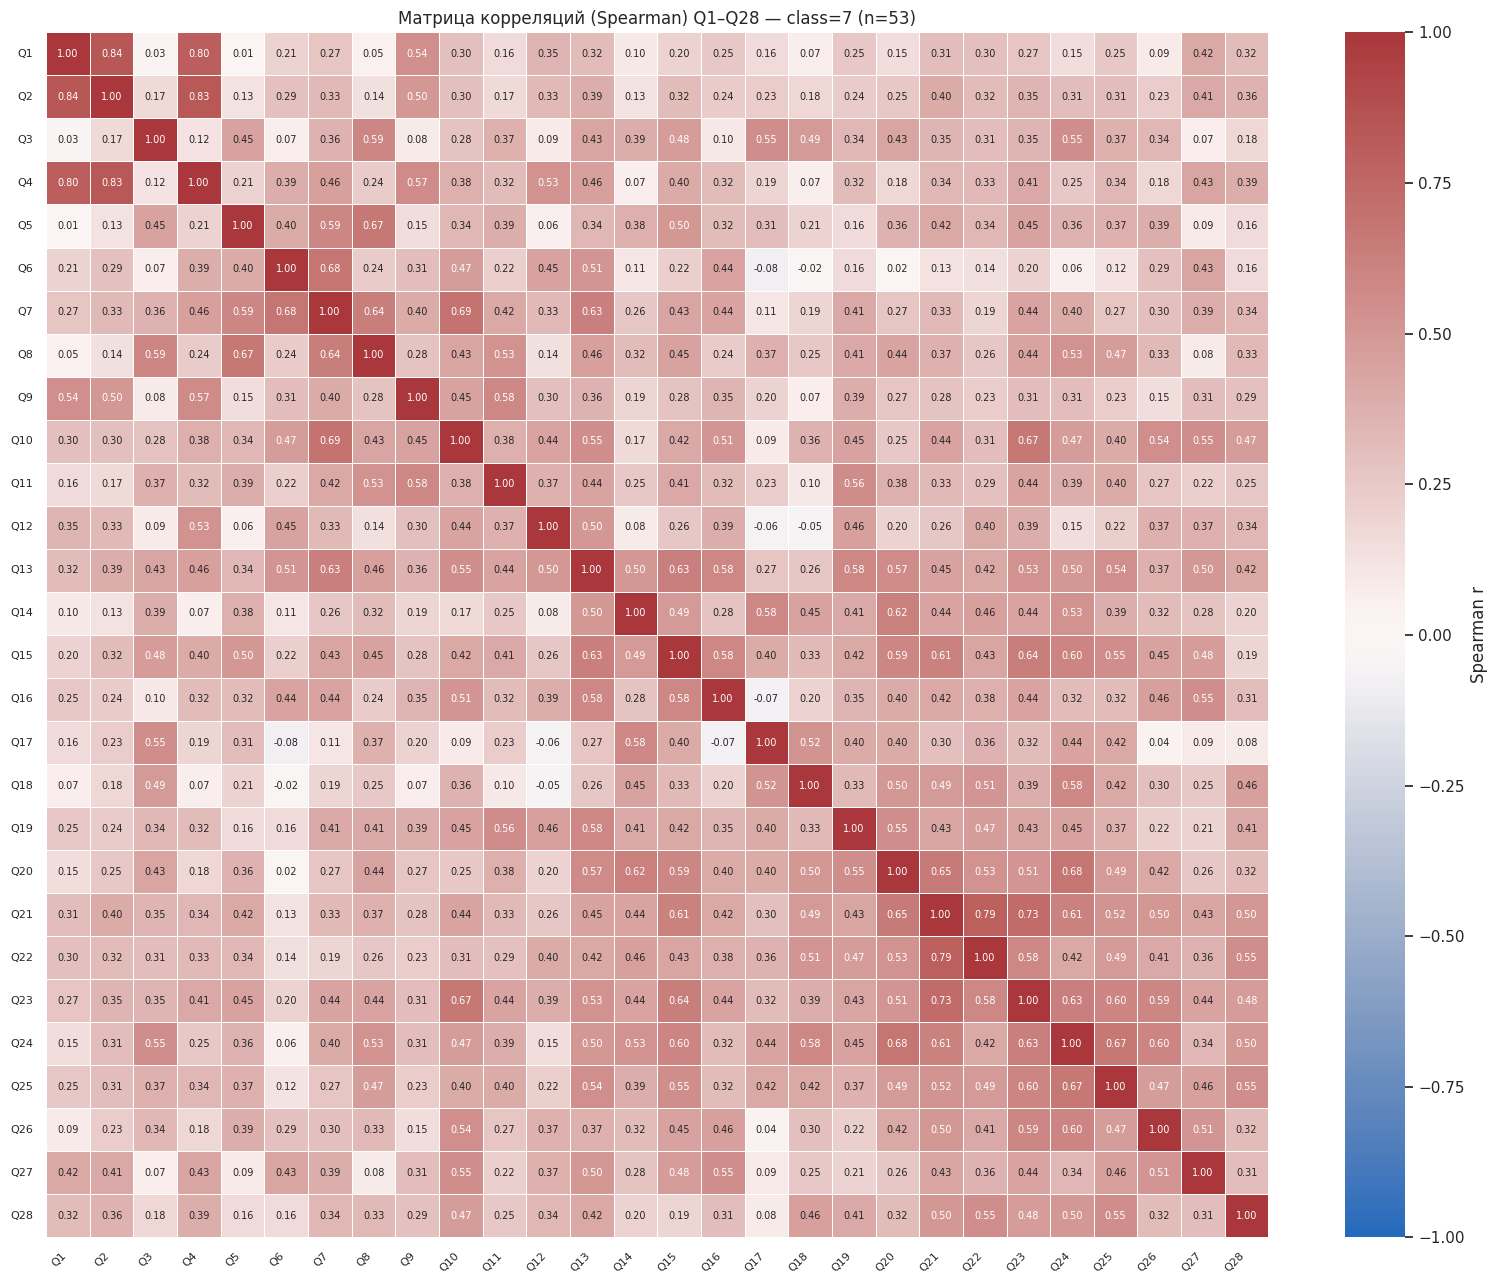

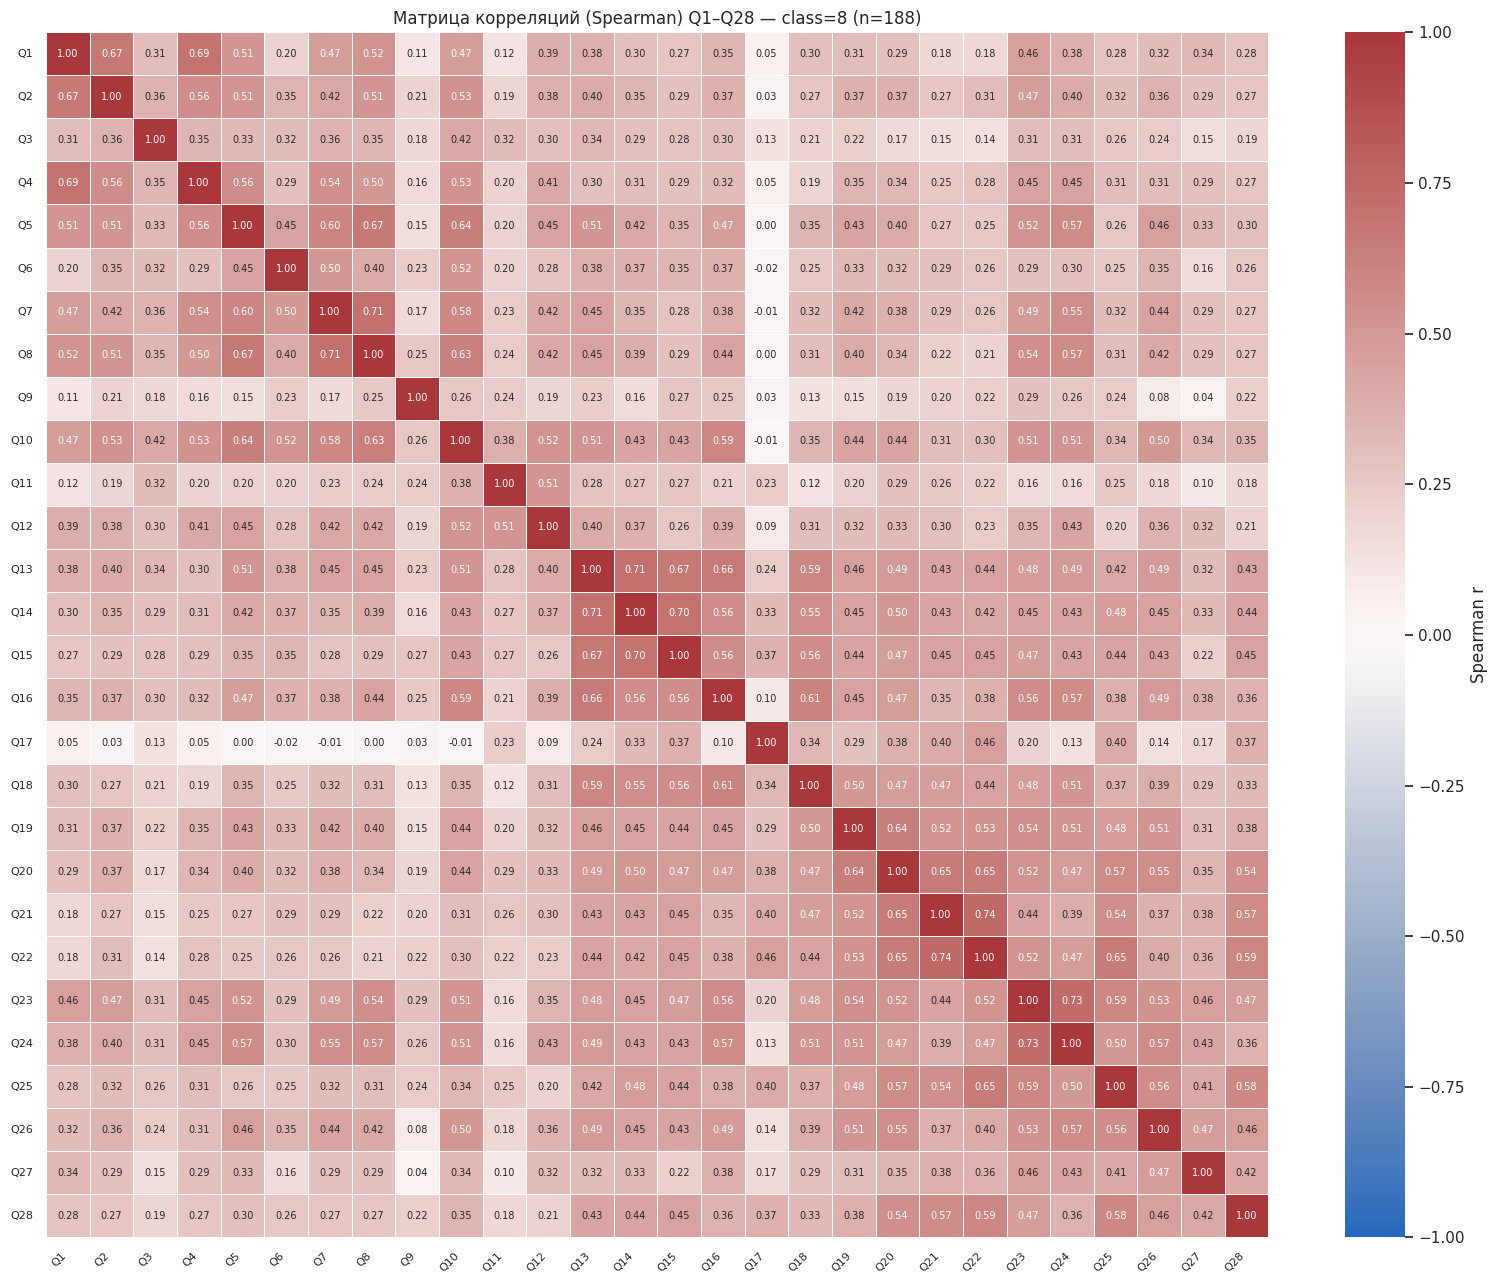

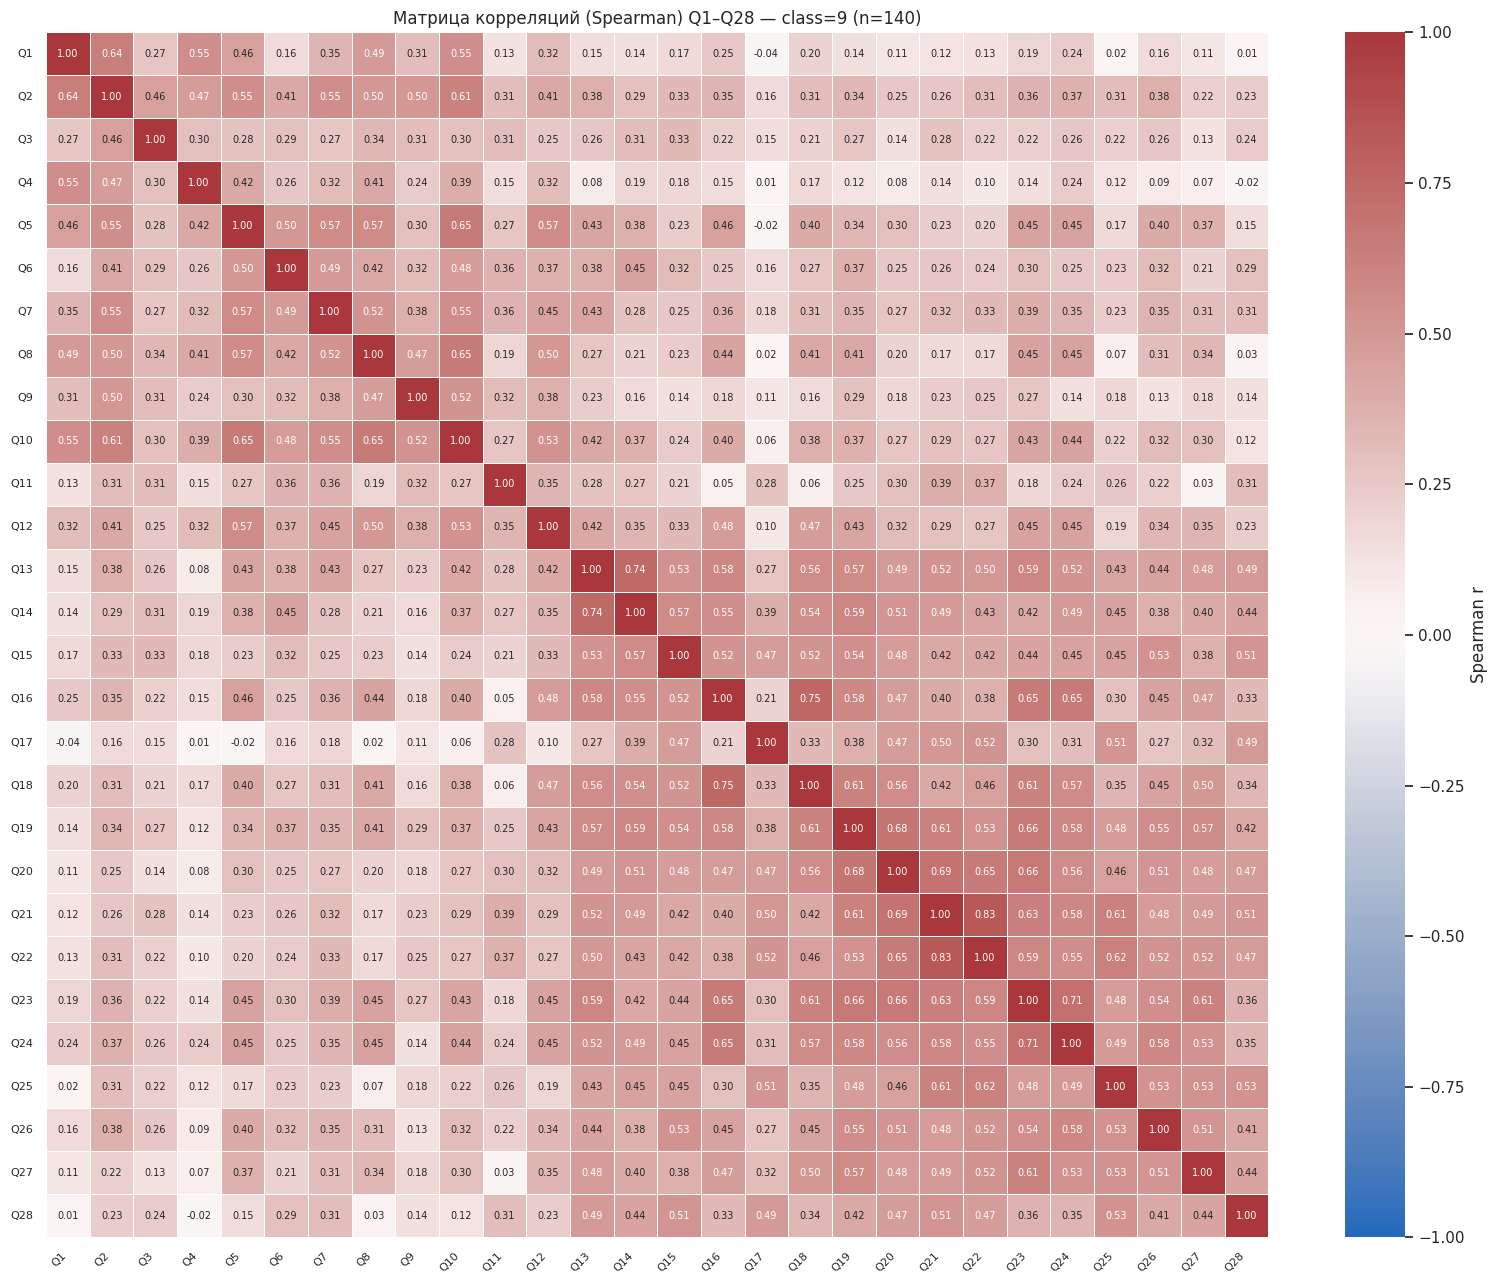

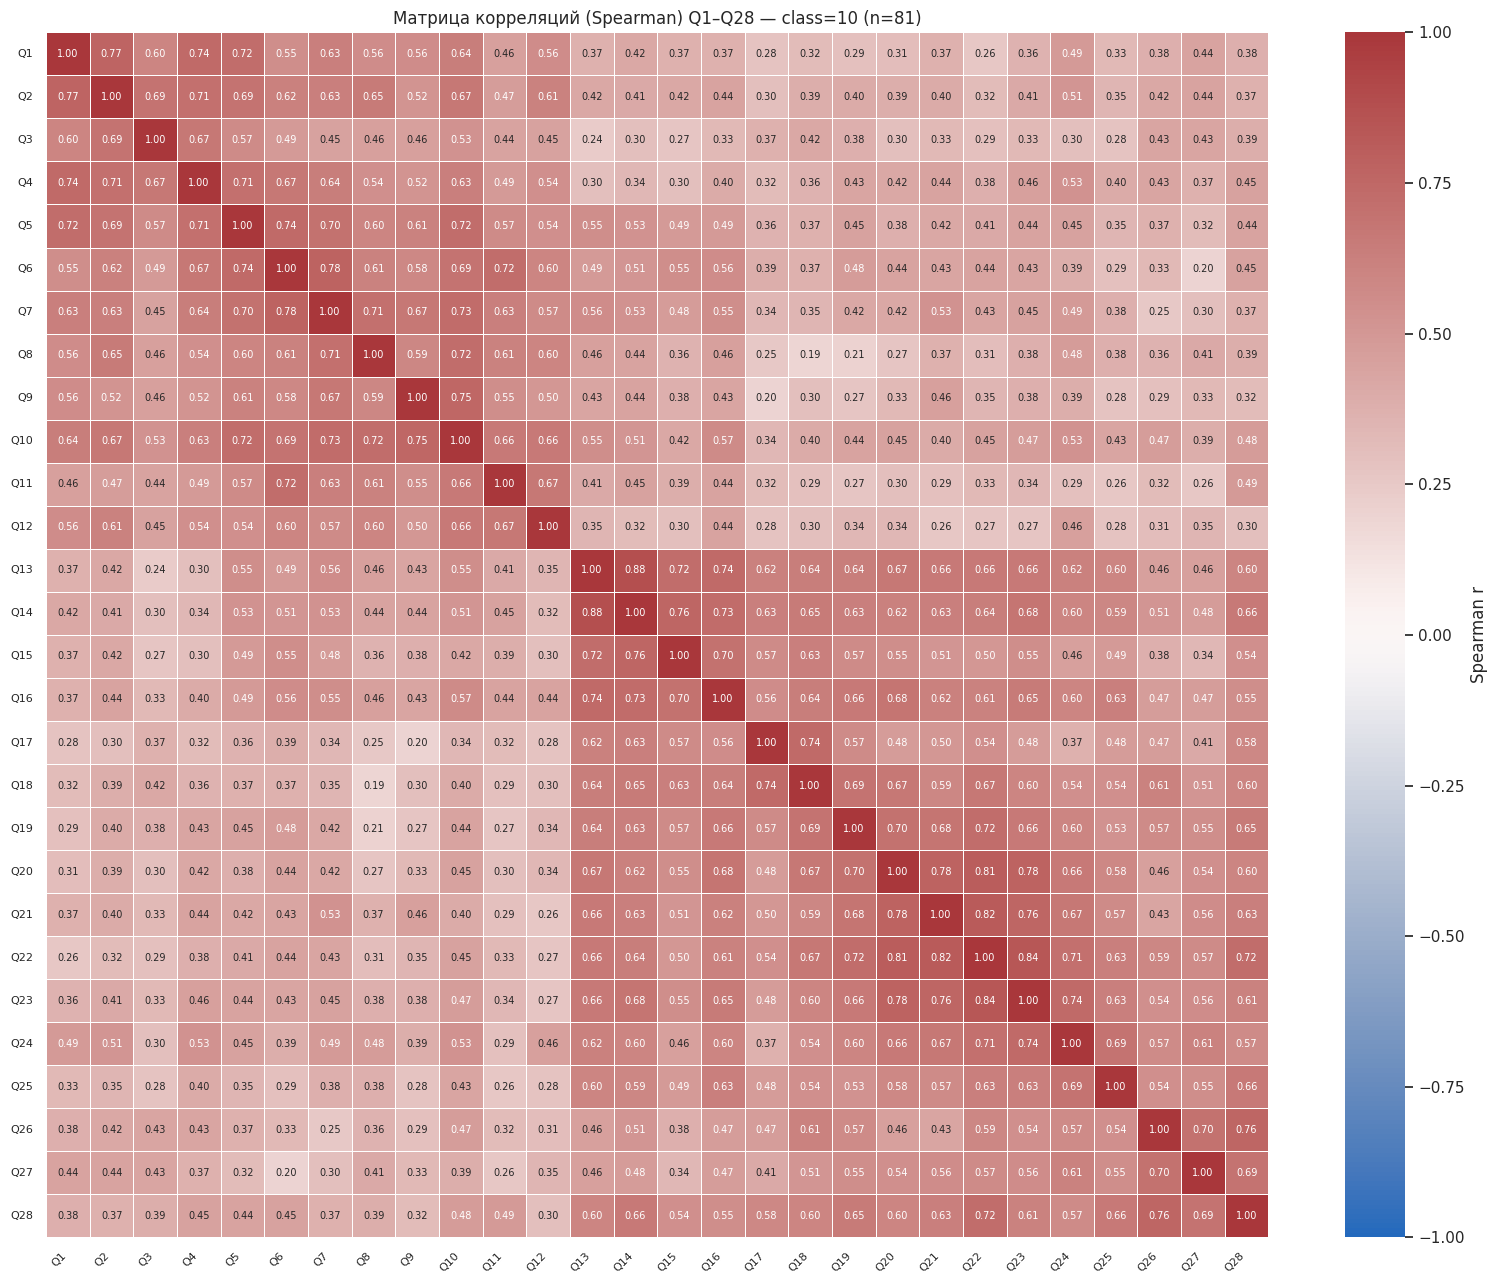

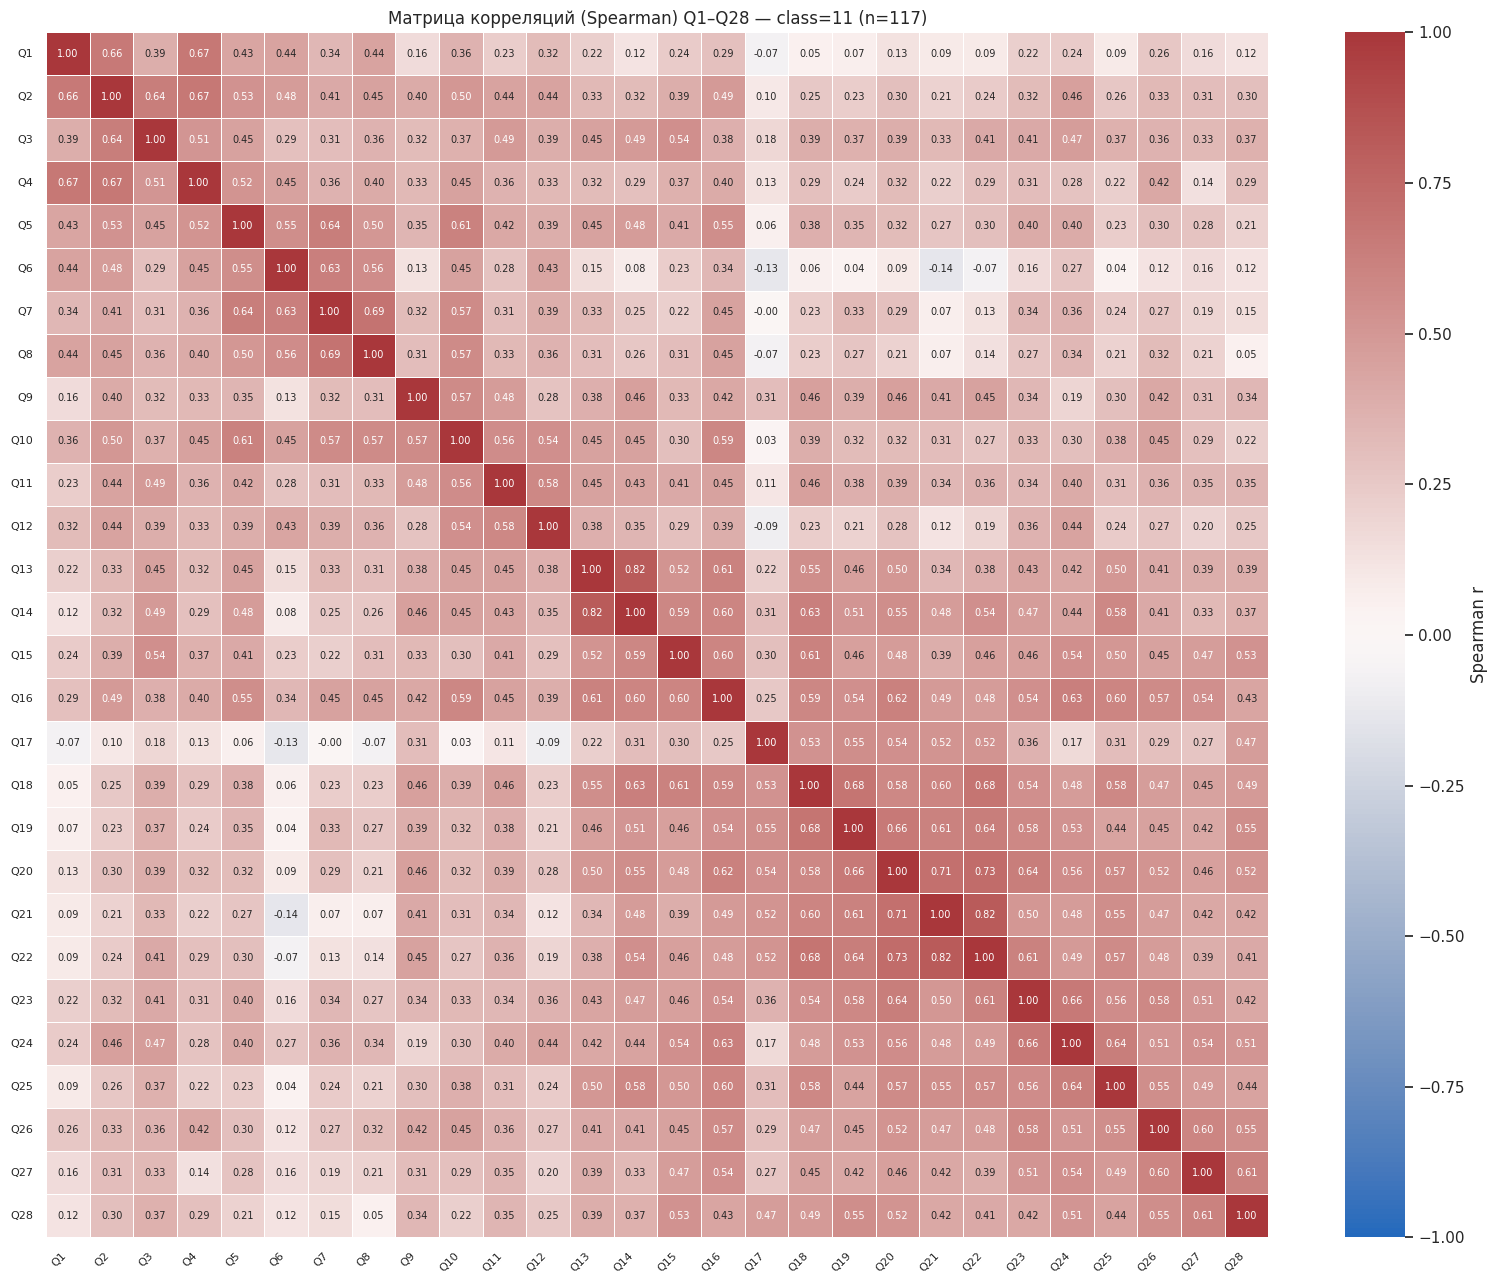

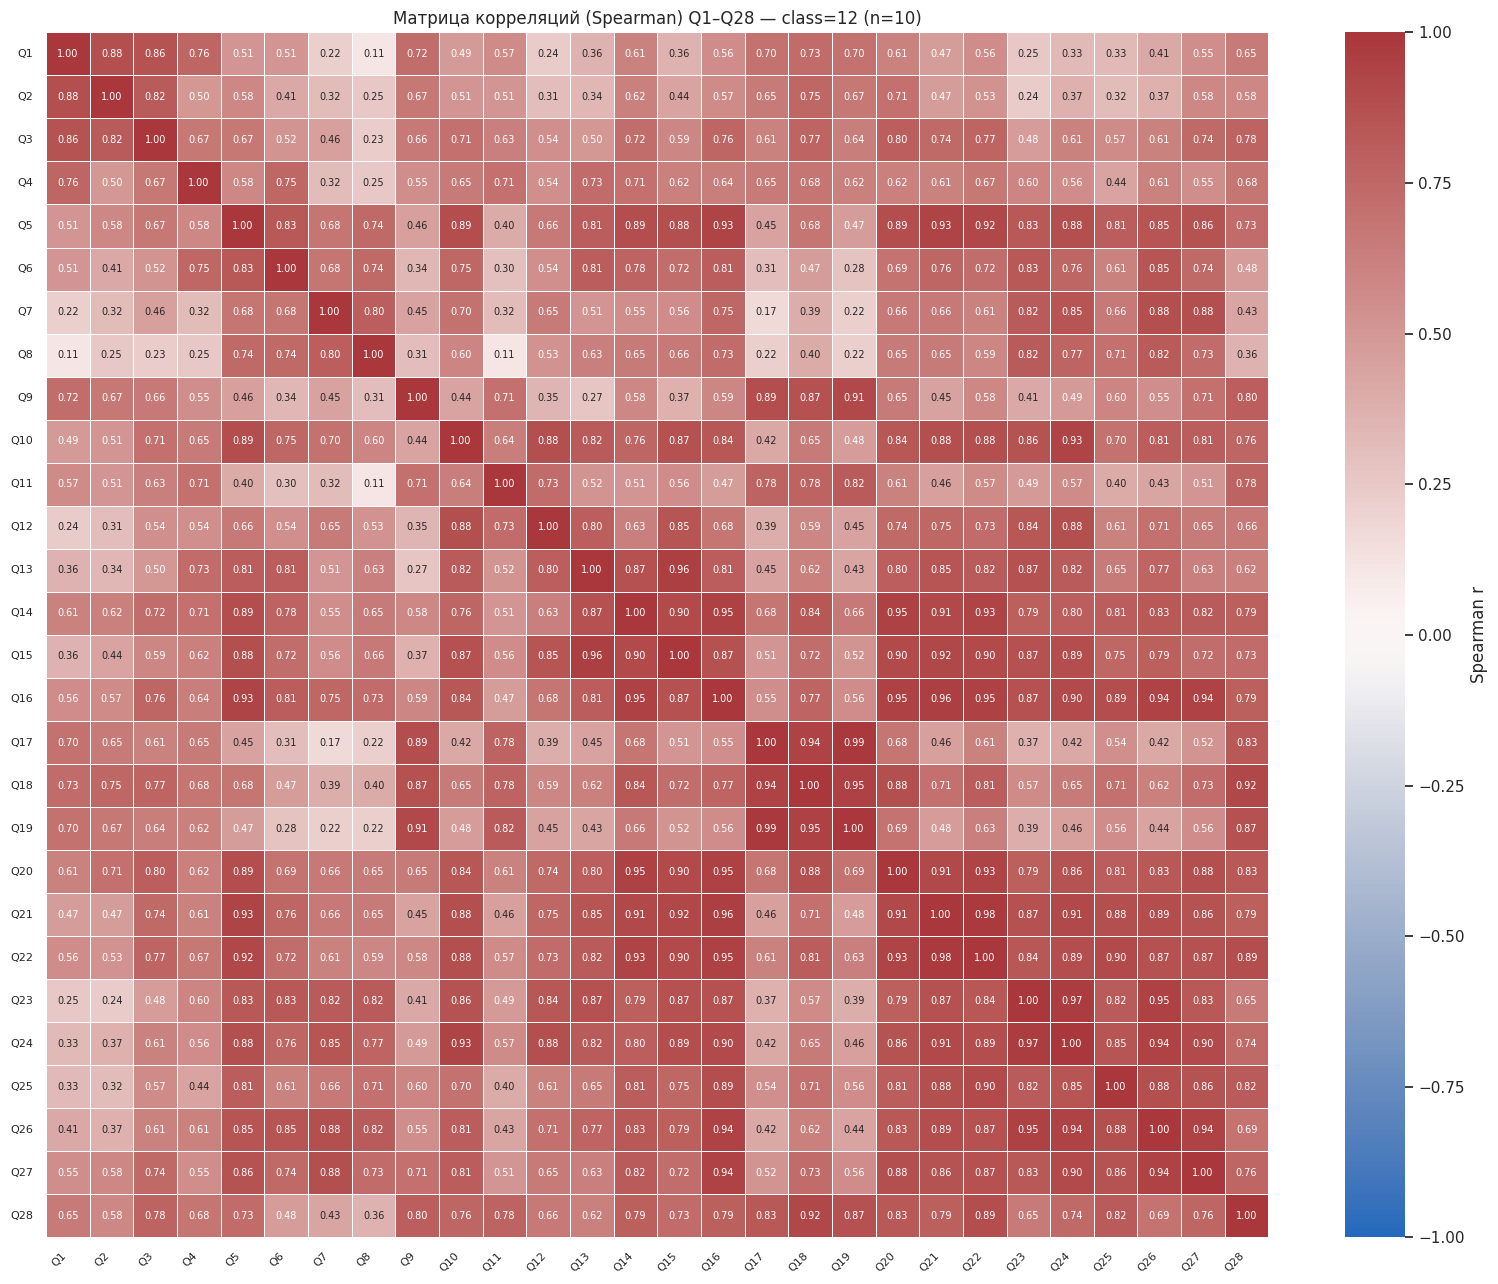

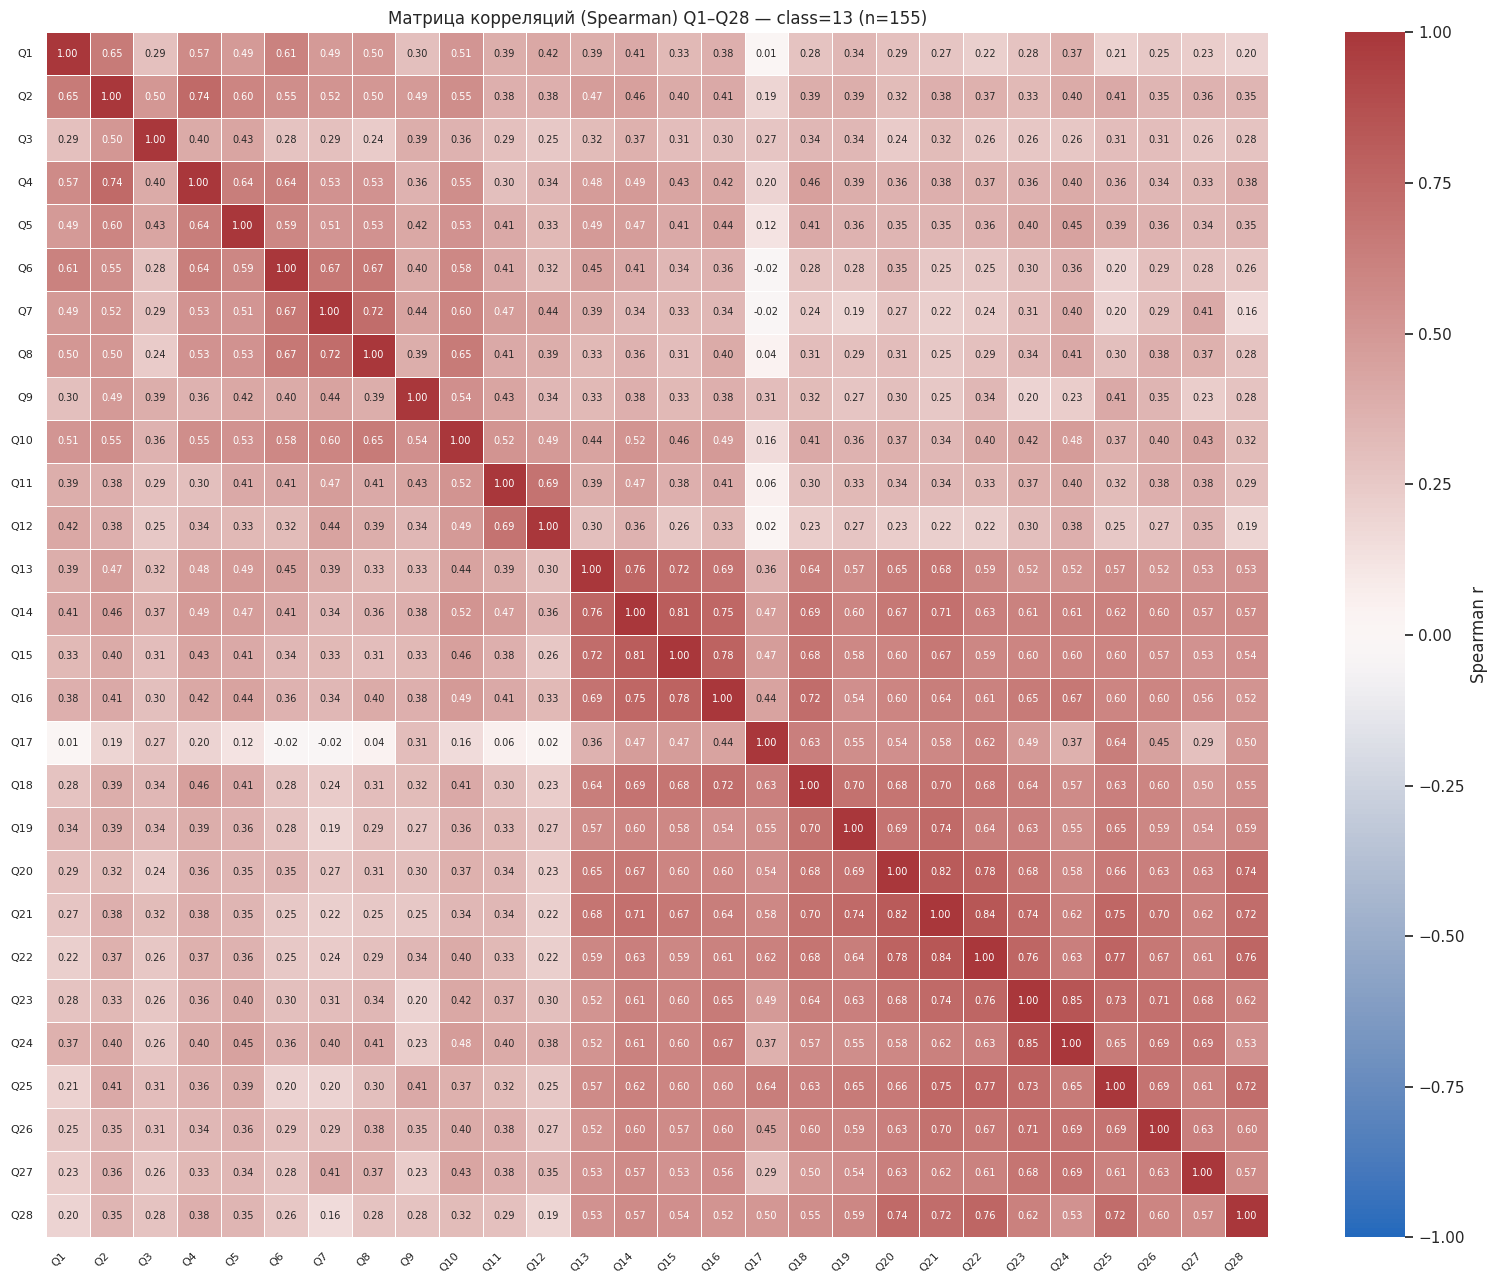

In [27]:

# --- 3) МАТРИЦЫ КОРРЕЛЯЦИЙ ДЛЯ КАЖДОГО КУРСА ---
# строим подробные heatmap (как в Задании 2) для всех курсов;
# при большом числе курсов это может занять время.
print("\n=== Построение матриц корреляций по каждому курсу ===")
for c in unique_classes_sorted:
    df_c = df_clean[df_clean["class"] == c]
    if len(df_c) < 2:
        print(f"Пропуск class={c}: слишком мало наблюдений (n={len(df_c)}).")
        continue
    corr_c = df_c[question_vars].corr(method="spearman").round(2)
    title = f"Матрица корреляций (Spearman) Q1–Q28 — class={c} (n={len(df_c)})"
    plot_corr_heatmap(corr_c, title=title)


**Анализ показал, что курсы с достаточным количеством данных (≥30 отзывов) демонстрируют устойчивые корреляционные структуры:
внутри тематических групп вопросов — высокие связи, между группами — умеренные или слабые.
Разные курсы различаются по степени согласованности ответов:
на одних студенты оценивают все аспекты примерно одинаково, на других — различают сильные и слабые стороны.
Это помогает выявить специфику восприятия разных дисциплин и преподавателей.**

## Задание 4. Описательная статистика и сравнение преподавателей

Считается, что **вопросы Q13–Q28** описывают именно аспекты работы преподавателя (знания, подготовленность, коммуникация, объективность и т.д.).  
Для каждого `instr` рассчитаем:
- число оценок;
- среднюю оценку по Q13–Q28, медиану, стандартное отклонение, мин/макс;
- 95% доверительный интервал для среднего;
- (опционально) профиль по категориям вопросов.


In [28]:

# =====================
# Столбцы, относящиеся к преподавателю: Q13–Q28
# =====================
teacher_q = [q for q in question_cols if 13 <= int(q[1:]) <= 28]
teacher_q[:5], teacher_q[-5:], len(teacher_q)


(['Q13', 'Q14', 'Q15', 'Q16', 'Q17'], ['Q24', 'Q25', 'Q26', 'Q27', 'Q28'], 16)

In [29]:

# =====================
# Агрегаты по преподавателям
# =====================
def ci95_mean(series):
    # t-CI для среднего
    x = series.dropna().values
    n = len(x)
    if n <= 1:
        return (np.nan, np.nan, np.nan)
    mean = np.mean(x)
    sd = np.std(x, ddof=1)
    se = sd / np.sqrt(n)
    t = stats.t.ppf(0.975, df=n-1)
    low, high = mean - t*se, mean + t*se
    return (mean, low, high)

rows = []
for instr_id, g in df_clean.groupby("instr"):
    vals = g[teacher_q].values.reshape(-1)
    vals = vals[~np.isnan(vals)]
    if len(vals) == 0:
        continue
    mean, low, high = ci95_mean(pd.Series(vals))
    rows.append({
        "instr": instr_id,
        "n_rows": len(g),
        "mean_Q13_28": np.mean(g[teacher_q].mean(axis=1)),
        "median_Q13_28": np.median(g[teacher_q].mean(axis=1)),
        "std_Q13_28": np.std(g[teacher_q].mean(axis=1), ddof=1),
        "min_Q13_28": np.min(g[teacher_q].mean(axis=1)),
        "max_Q13_28": np.max(g[teacher_q].mean(axis=1)),
        "CI95_mean_all_values_low": low,
        "CI95_mean_all_values_high": high,
    })

instructor_stats = pd.DataFrame(rows).sort_values("mean_Q13_28", ascending=False)
display(instructor_stats)


,instr,n_rows,mean_Q13_28,median_Q13_28,std_Q13_28,min_Q13_28,max_Q13_28,CI95_mean_all_values_low,CI95_mean_all_values_high
1,2,329,3.622910,3.7500,0.842370,1.0,5.0,3.593337,3.652484
0,1,149,3.409815,3.4375,0.861423,1.0,5.0,3.364122,3.455509
2,3,844,3.359375,3.3750,0.853930,1.0,5.0,3.339708,3.379042


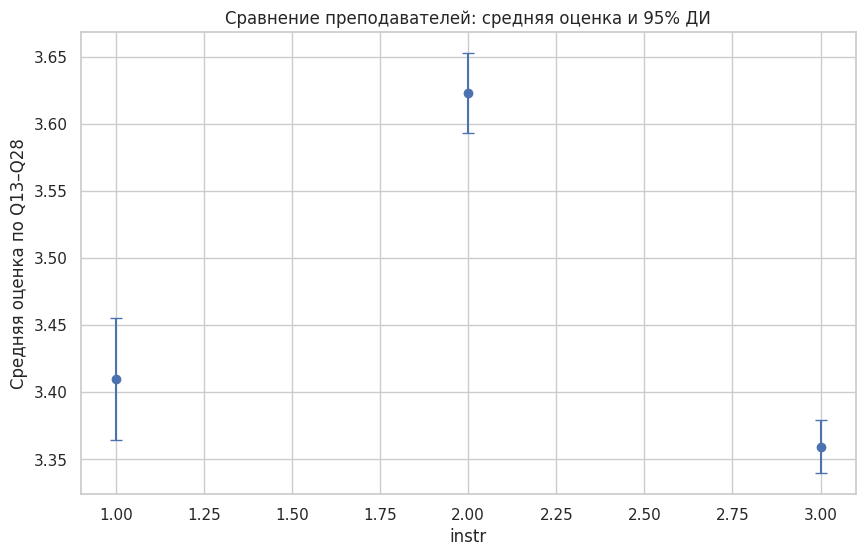

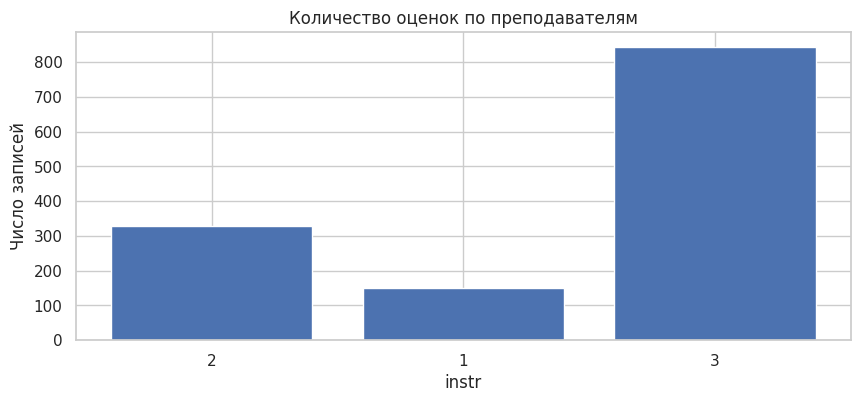

,Подача и структура,Коммуникация и взаимодействие,Компетентность и подготовка,Оценивание и обратная связь
instr,,,,
1,3.42,3.55,3.33,3.34
2,3.57,3.78,3.60,3.53
3,3.30,3.45,3.33,3.36


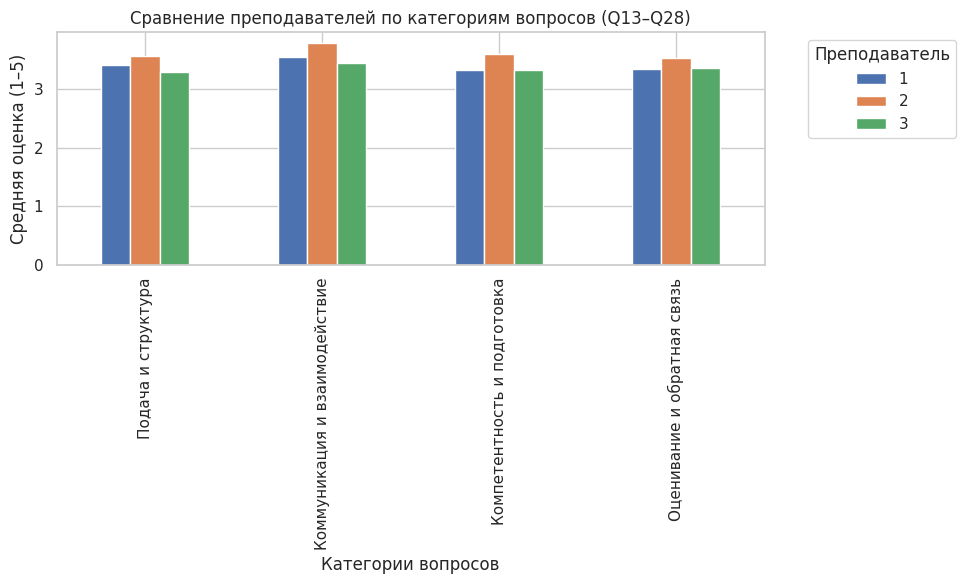

In [35]:

# Визуализация: средние оценки по преподавателям (с доверительными интервалами)
plt.figure(figsize=(10,6))
tmp = instructor_stats.copy()
tmp["err_low"] = tmp["mean_Q13_28"] - tmp["CI95_mean_all_values_low"]
tmp["err_high"] = tmp["CI95_mean_all_values_high"] - tmp["mean_Q13_28"]
plt.errorbar(tmp["instr"], tmp["mean_Q13_28"],
             yerr=[tmp["err_low"], tmp["err_high"]], fmt='o', capsize=4)
plt.xlabel("instr")
plt.ylabel("Средняя оценка по Q13–Q28")
plt.title("Сравнение преподавателей: средняя оценка и 95% ДИ")
plt.show()

# Количество записей (надёжность средних)
plt.figure(figsize=(10,4))
plt.bar(instructor_stats["instr"].astype(str), instructor_stats["n_rows"])
plt.xlabel("instr")
plt.ylabel("Число записей")
plt.title("Количество оценок по преподавателям")
plt.show()

# =====================
# Сравнение преподавателей по категориям вопросов (Q13–Q28)
# =====================

# Категории вопросов: можно изменить границы при необходимости
categories = {
    "Подача и структура": [f"Q{i}" for i in range(13, 17)],
    "Коммуникация и взаимодействие": [f"Q{i}" for i in range(17, 21)],
    "Компетентность и подготовка": [f"Q{i}" for i in range(21, 25)],
    "Оценивание и обратная связь": [f"Q{i}" for i in range(25, 29)],
}

# Расчёт средних значений по категориям для каждого преподавателя
category_means = []
for instr_id, g in df_clean.groupby("instr"):
    cat_scores = {cat: g[q_list].mean(axis=1).mean() for cat, q_list in categories.items()}
    cat_scores["instr"] = instr_id
    category_means.append(cat_scores)

df_instr_cats = pd.DataFrame(category_means).set_index("instr")
display(df_instr_cats.round(2))

# --- Вариант 1: группированный bar-график ---
df_instr_cats.T.plot(kind="bar", figsize=(10, 6))
plt.title("Сравнение преподавателей по категориям вопросов (Q13–Q28)")
plt.xlabel("Категории вопросов")
plt.ylabel("Средняя оценка (1–5)")
plt.legend(title="Преподаватель", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()



**Анализ преподавателей по средним оценкам и доверительным интервалам показал, что существуют различия не только по уровню оценок, но и по устойчивости этих оценок.
Преподаватели с большим количеством отзывов имеют более надёжные оценки.
Сравнение профилей по категориям вопросов выявило, что преподаватели могут быть сильнее в разных аспектах — например, в подаче материала или в обратной связи со студентами.**

## Задание 5. Описательная статистика и сравнение предметов

Для каждого `class` посчитаем:
- число оценок, общую среднюю и медиану (по Q1–Q28),
- стандартное отклонение, мин/макс,
- среднюю сложность `difficulty`,
- среднюю посещаемость `attendance`.

Построим графики: средняя оценка по предметам, средняя сложность, средняя посещаемость, а также диаграмму рассеяния «оценка vs сложность».


In [31]:

# =====================
# Агрегаты по предметам (class)
# =====================
def agg_for_class(group):
    mean_q = group[question_cols].mean(axis=1)
    out = {
        "n": len(group),
        "mean_allQ": float(mean_q.mean()),
        "median_allQ": float(np.median(mean_q)),
        "std_allQ": float(np.std(mean_q, ddof=1)),
        "min_allQ": float(mean_q.min()),
        "max_allQ": float(mean_q.max()),
    }
    if "difficulty" in group.columns:
        out["mean_difficulty"] = float(group["difficulty"].mean())
    if "attendance" in group.columns:
        out["mean_attendance"] = float(group["attendance"].mean())
    return pd.Series(out)

class_stats = df_clean.groupby("class").apply(agg_for_class).reset_index()
display(class_stats.sort_values("mean_allQ", ascending=False))


/tmp/ipython-input-2871703201.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  class_stats = df_clean.groupby("class").apply(agg_for_class).reset_index()


,class,n,mean_allQ,median_allQ,std_allQ,min_allQ,max_allQ,mean_difficulty,mean_attendance
0,1,62.0,3.453341,3.428571,0.731885,1.392857,4.571429,2.903226,2.645161
1,2,15.0,3.369048,3.392857,0.815045,1.714286,4.535714,3.533333,1.866667
9,10,81.0,3.368166,3.428571,0.775412,1.500000,4.678571,3.049383,2.567901
5,6,118.0,3.338983,3.375000,0.740716,1.428571,4.642857,2.771186,2.423729
10,11,117.0,3.326923,3.428571,0.705762,1.535714,4.500000,3.512821,2.564103
7,8,188.0,3.216375,3.196429,0.697533,1.500000,4.642857,3.303191,3.000000
6,7,53.0,3.211590,3.214286,0.659501,1.571429,4.607143,4.018868,2.773585
4,5,164.0,3.154181,3.160714,0.743695,1.321429,4.642857,3.506098,2.493902
12,13,155.0,3.151613,3.178571,0.833175,1.392857,4.607143,2.806452,2.516129
8,9,140.0,3.137245,3.142857,0.678000,1.500000,4.607143,3.200000,2.371429


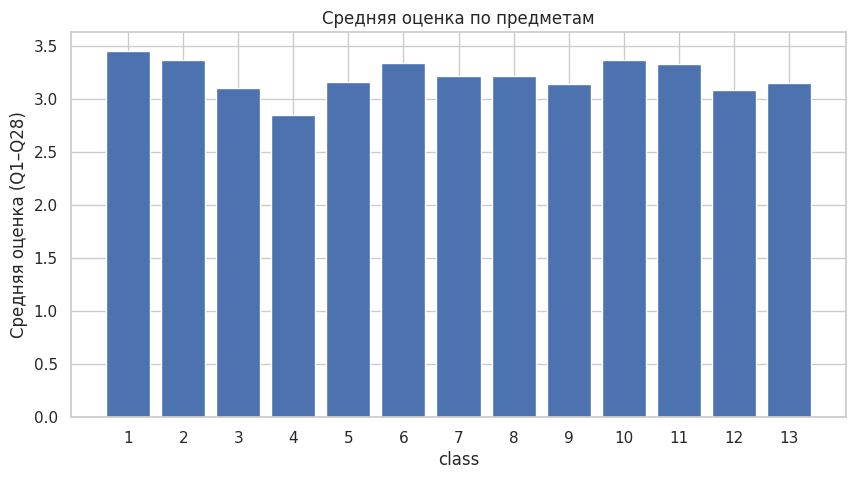

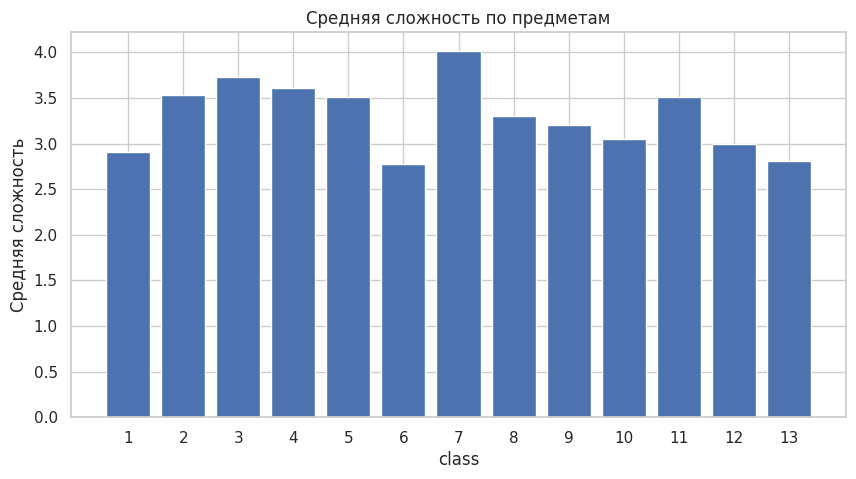

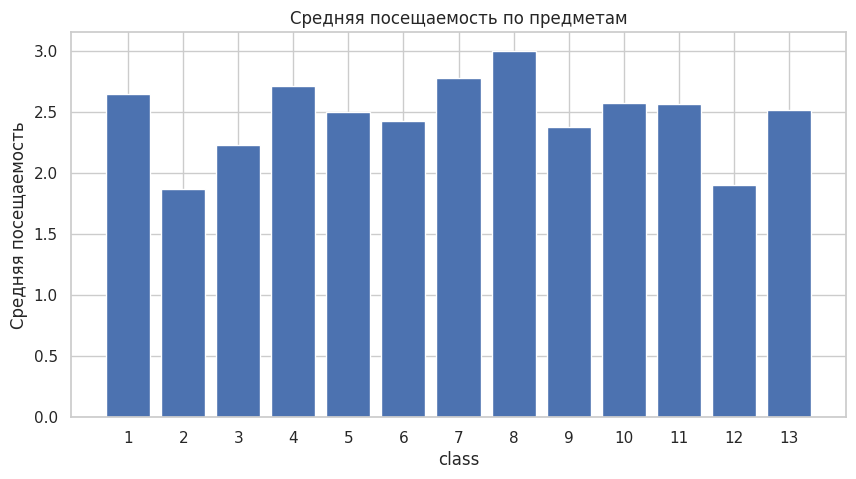

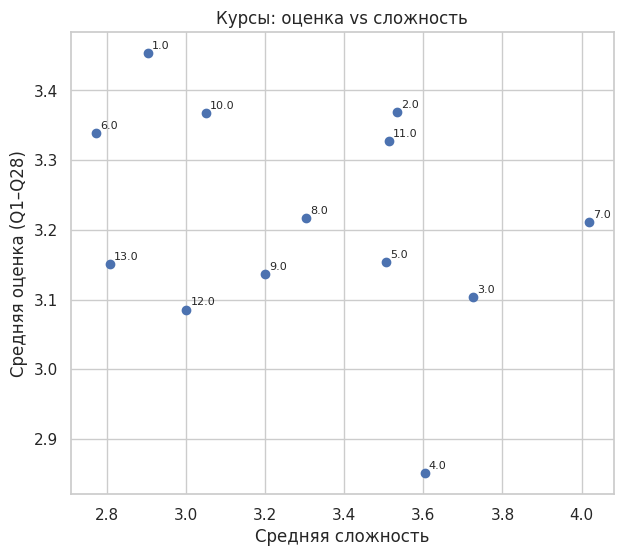

In [32]:

# Визуализации по предметам
fig, ax = plt.subplots(figsize=(10,5))
ax.bar(class_stats["class"].astype(str), class_stats["mean_allQ"])
ax.set_xlabel("class")
ax.set_ylabel("Средняя оценка (Q1–Q28)")
ax.set_title("Средняя оценка по предметам")
plt.xticks(rotation=0)
plt.show()

if "mean_difficulty" in class_stats.columns:
    fig, ax = plt.subplots(figsize=(10,5))
    ax.bar(class_stats["class"].astype(str), class_stats["mean_difficulty"])
    ax.set_xlabel("class")
    ax.set_ylabel("Средняя сложность")
    ax.set_title("Средняя сложность по предметам")
    plt.show()

if "mean_attendance" in class_stats.columns:
    fig, ax = plt.subplots(figsize=(10,5))
    ax.bar(class_stats["class"].astype(str), class_stats["mean_attendance"])
    ax.set_xlabel("class")
    ax.set_ylabel("Средняя посещаемость")
    ax.set_title("Средняя посещаемость по предметам")
    plt.show()

# Scatter: оценка vs сложность
if set(["mean_allQ","mean_difficulty"]).issubset(class_stats.columns):
    fig, ax = plt.subplots(figsize=(7,6))
    ax.scatter(class_stats["mean_difficulty"], class_stats["mean_allQ"])
    for i, row in class_stats.iterrows():
        ax.annotate(str(row["class"]), (row["mean_difficulty"], row["mean_allQ"]), xytext=(3,3), textcoords="offset points", fontsize=8)
    ax.set_xlabel("Средняя сложность")
    ax.set_ylabel("Средняя оценка (Q1–Q28)")
    ax.set_title("Курсы: оценка vs сложность")
    plt.show()


**Сравнение предметов по средней оценке, сложности и посещаемости показало, что между этими переменными есть определённые закономерности.
Некоторые курсы демонстрируют высокие оценки при высокой сложности — что может свидетельствовать о качественном преподавании сложного материала.
Другие предметы получают более низкие оценки при низкой сложности, что указывает на возможные проблемы в организации или интересе студентов.
Эти данные позволяют выявить предметы с наилучшим сочетанием сложности и удовлетворённости студентов.**

## Выводы

- Применены критерии очистки, релевантные опросам: убраны записи с нулевой посещаемостью и стрейтлайнингом (≥ 70% одинаковых ответов); опционально — дубликаты.
- Проведён корреляционный анализ (Spearman) по `Q1–Q28` (+ `difficulty`) с визуализацией и выводом пар по уровням силы связи.
- Выполнено сравнение матриц корреляций для разных предметов (метрики средней |r|, числа сильных связей и фробениусовой дистанции до общей матрицы).
- Рассчитаны описательные статистики по преподавателям (Q13–Q28) с 95% доверительными интервалами и визуализациями.
- Рассчитаны описательные статистики по предметам с графиками и диаграммой «оценка vs сложность».
- Основные интерпретации следует делать с учётом объёмов данных и особенностей курсов/преподавателей.
